# TCN-Transformer Log Anomaly Notebook

Run All и всё. Тетрадка сама проходит по нескольким датасетам, при необходимости готовит данные, запускает обучение/evaluation/report assets и показывает общие метрики. Код моделей, XAI, графиков и preprocessing остаётся в `src/` и `scripts/`.


In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)

dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
run_stage = notebook_workflow.run_stage

PROJECT_ROOT


PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer')

## Настройки

По умолчанию запускаются все три датасета в RAM-safe режиме. Если нужно ещё легче, оставь в `DATASETS` только один датасет.


In [2]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)

dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
run_stage = notebook_workflow.run_stage

DATASETS = ['lo2', 'loghub2', 'rcaeval']  # варианты: 'lo2', 'loghub2', 'rcaeval', 'demo'
FORCE_PREPARE = False
FORCE_TRAIN = False  # поставь True, если надо переобучить уже существующие checkpoints на 100 эпох
RUN_ENSEMBLE = True
RUN_EVALUATION = True
RUN_REPORT = True
FULL_DATA = False  # True жрёт RAM: снимает caps и грузит весь raw сразу
MEMORY_SAVER = True  # щадящий RAM/VRAM режим для ноутбука
MEMORY_BATCH_SIZE = 8
MAX_LOCALIZATION_SAMPLES = 128  # сколько synthetic samples брать для XAI/heatmap
TRAINING_EPOCHS = 100
TRAINING_PATIENCE = 8
NOTEBOOK_COMPACT_LOGS = False  # не чистим training logs, чтобы можно было листать эпохи

CONFIG_BY_DATASET = {
    'lo2': PROJECT_ROOT / 'configs' / 'experiment_lo2.yaml',
    'loghub2': PROJECT_ROOT / 'configs' / 'experiment_loghub.yaml',
    'rcaeval': PROJECT_ROOT / 'configs' / 'experiment_rcaeval.yaml',
    'demo': PROJECT_ROOT / 'configs' / 'experiment_demo.yaml',
}

DATASET_STATE = {}
for dataset_name in DATASETS:
    base_config_path = CONFIG_BY_DATASET[dataset_name]
    base_config = load_config(base_config_path)
    output_dir = PROJECT_ROOT / 'outputs' / dataset_name
    config_factory = make_full_data_config if FULL_DATA else make_notebook_config
    notebook_config_path = config_factory(base_config_path, dataset_name=dataset_name, output_dir=output_dir)
    if MEMORY_SAVER:
        notebook_config_path = make_memory_saver_config(
            notebook_config_path,
            dataset_name=dataset_name,
            output_dir=output_dir,
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
        )
    notebook_config = load_config(notebook_config_path)
    used_config_path = PROJECT_ROOT / notebook_config['data']['processed_dir'] / 'used_config.yaml'
    DATASET_STATE[dataset_name] = {
        'base_config_path': base_config_path,
        'notebook_config_path': notebook_config_path,
        'used_config_path': used_config_path,
        'output_dir': output_dir,
    }

DATASET_STATE


{'lo2': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_lo2.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/lo2_memory_saver_notebook_config.yaml'),
  'used_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/lo2/used_config.yaml'),
  'output_dir': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/lo2')},
 'loghub2': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_loghub.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/loghub2_memory_saver_notebook_config.yaml'),
  'used_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/loghub2/used_c

## Датасеты

Справка по источникам и папкам raw-данных.


In [3]:
dataset_links_table()


,dataset,target_dir,url,note
0,lo2,data/raw/lo2,https://doi.org/10.5281/zenodo.14265858,LO2 / Light-OAuth2 microservice API anomaly da...
1,loghub2,data/raw/loghub2,https://zenodo.org/records/8275861,Loghub-2.0 collection. Put extracted log files...
2,rcaeval,data/raw/rcaeval,https://github.com/phamquiluan/RCAEval,RCAEval benchmark repository/data. Put extract...


## Баланс Данных

Перед обучением видно, сколько normal/anomaly уже лежит в подготовленных split-файлах. В RAM-safe режиме `FULL_DATA=False`, поэтому используются лимиты из YAML-конфигов и готовые splits переиспользуются, если они уже есть.


In [4]:
label_summary = split_label_summary(DATASET_STATE)
real_synthetic_summary = real_vs_synthetic_label_summary(DATASET_STATE)
real_synthetic_summary


,dataset,source,normal,anomaly,total
0,lo2,real,140,2670,2810
1,lo2,synthetic,12,10,22
2,lo2,real+synthetic,152,2680,2832
3,loghub2,real,1563,0,1563
4,loghub2,synthetic,119,131,250
5,loghub2,real+synthetic,1682,131,1813
6,rcaeval,real,5450,999,6449
7,rcaeval,synthetic,460,412,872
8,rcaeval,real+synthetic,5910,1411,7321
9,ALL,real,7153,3669,10822


### Детализация По Split

Если нужно посмотреть train/val/test/test_synthetic отдельно, эта таблица ниже.


In [5]:
label_summary


,dataset,split,normal,anomaly,total,status
0,lo2,train,90,0,90,ok
1,lo2,val,22,1187,1209,ok
2,lo2,test,28,1483,1511,ok
3,lo2,test_synthetic,12,10,22,ok
4,loghub2,train,1000,0,1000,ok
5,loghub2,val,250,0,250,ok
6,loghub2,test,313,0,313,ok
7,loghub2,test_synthetic,119,131,250,ok
8,rcaeval,train,3488,0,3488,ok
9,rcaeval,val,872,444,1316,ok


## Автозапуск Pipeline По Всем Датасетам

Эта ячейка делает всю работу. Для каждого датасета результаты пишутся в свою папку: `outputs/lo2`, `outputs/loghub2`, `outputs/rcaeval`.


In [6]:
def model_checkpoint(output_dir, model_name):
    return output_dir / 'models' / f'{model_name}_best.pt'

for dataset_name, state in DATASET_STATE.items():
    print('=' * 80)
    print(f'DATASET: {dataset_name}')
    print('=' * 80)

    prepare_needed = FORCE_PREPARE or not state['used_config_path'].exists()
    if prepare_needed:
        print(f'Preparing data from {state["notebook_config_path"]} ...')
        run_stage('prepare_data', state['notebook_config_path'])
    else:
        print(f'Prepared config already exists: {state["used_config_path"]}')

    config_path_for_run = state['used_config_path'] if state['used_config_path'].exists() else state['notebook_config_path']
    if MEMORY_SAVER:
        config_path_for_run = make_memory_saver_config(
            config_path_for_run,
            dataset_name=dataset_name,
            output_dir=state['output_dir'],
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
        )
    else:
        config_path_for_run = make_notebook_config(config_path_for_run, dataset_name=dataset_name, output_dir=state['output_dir'])

    config = load_config(config_path_for_run)
    config.setdefault('notebook', {})['compact_training_log'] = NOTEBOOK_COMPACT_LOGS
    save_config(config, config_path_for_run)
    config = load_config(config_path_for_run)

    training = config['training']
    print({
        'config': str(config_path_for_run),
        'output_dir': config['project']['output_dir'],
        'epochs': training['epochs'],
        'patience': training['patience'],
        'batch_size': training['batch_size'],
        'device': training['device'],
        'target_recall': config.get('threshold', {}).get('target_recall'),
    })

    for model_name, stage in [('tcn_ae', 'train_tcn_ae'), ('tcn_transformer_ae', 'train_tcn_transformer_ae')]:
        ckpt = model_checkpoint(state['output_dir'], model_name)
        if FORCE_TRAIN or not ckpt.exists():
            print()
            print(f'Training {dataset_name}/{model_name} ...')
            run_stage(stage, config_path_for_run)
        else:
            print(f'Skip training {dataset_name}/{model_name}: checkpoint exists -> {ckpt}')

    ensemble_enabled = bool(config.get('ensemble', {}).get('enabled', False)) and RUN_ENSEMBLE
    if ensemble_enabled:
        member_seeds = config.get('ensemble', {}).get('member_seeds', [])
        missing_members = [
            seed for seed in member_seeds
            if not (state['output_dir'] / 'models' / f'tcn_transformer_ae_seed{int(seed)}_best.pt').exists()
        ]
        if FORCE_TRAIN or missing_members:
            print()
            print(f'Training {dataset_name}/transformer ensemble; missing_members={missing_members}')
            run_stage('train_tcn_transformer_ensemble', config_path_for_run)
        else:
            print(f'Skip ensemble training for {dataset_name}: all member checkpoints exist')
    else:
        print(f'Skip ensemble training for {dataset_name}: disabled by config or RUN_ENSEMBLE=False')

    if RUN_EVALUATION:
        for stage in ['evaluate_detection', 'evaluate_localization', 'evaluate_adaptive_threshold']:
            print()
            print(f'Running {dataset_name}/{stage} ...')
            run_stage(stage, config_path_for_run)

    if RUN_REPORT:
        print()
        print(f'Generating report assets for {dataset_name} ...')
        run_stage('generate_report_assets', config_path_for_run)

print()
print('Done. Per-dataset outputs are in outputs/<dataset_name>/.')


DATASET: lo2
Prepared config already exists: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/lo2/used_config.yaml
{'config': '/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/lo2_memory_saver_notebook_config.yaml', 'output_dir': '/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/lo2', 'epochs': 100, 'patience': 8, 'batch_size': 8, 'device': 'cuda', 'target_recall': 1.0}

Training lo2/tcn_ae ...
tcn_ae: start training | epochs=100 patience=8 batch_size=8 device=cuda params=8,830,522 best_checkpoint=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/lo2/models/tcn_ae_best.pt
tcn_ae epoch=001/100 train_loss=9.7789 val_loss=8.6015 val_f1=0.9908 val_recall=1.0000 val_fp=22 val_fn=0 thr=6.36761 safety=True best_val_loss=8.6015 BEST saved time=1.9s
tcn_ae epoch=002/100 train_loss=7.4200 val_loss=6.6682 val_f1=0.9908 val_recall=1.0000 val_fp=22 val_fn=0 thr=2.80945 safety=

/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


tcn_ae epoch=001/100 train_loss=0.5690 val_loss=0.0290 val_f1=0.0000 val_recall=0.0000 val_fp=18 val_fn=0 thr=0.0788977 safety=False best_val_loss=0.0290 BEST saved time=0.6s


/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


tcn_ae epoch=002/100 train_loss=0.0129 val_loss=0.0112 val_f1=0.0000 val_recall=0.0000 val_fp=21 val_fn=0 thr=0.0335828 safety=False best_val_loss=0.0112 BEST saved time=0.7s


...

tcn_transformer_ae epoch=062/100 train_loss=0.0000 val_loss=0.0011 val_f1=0.0000 val_recall=0.0000 val_fp=22 val_fn=0 thr=9.31008e-06 safety=False best_val_loss=0.0011 no improvement 6/8 time=1.1s


/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


tcn_transformer_ae epoch=063/100 train_loss=0.0000 val_loss=0.0011 val_f1=0.0000 val_recall=0.0000 val_fp=20 val_fn=0 thr=8.70009e-06 safety=False best_val_loss=0.0011 no improvement 7/8 time=1.2s


/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/danderety/jupyter/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


tcn_transformer_ae epoch=064/100 train_loss=0.0000 val_loss=0.0011 val_f1=0.0000 val_recall=0.0000 val_fp=20 val_fn=0 thr=8.10703e-06 safety=False best_val_loss=0.0011 no improvement 8/8 time=1.2s
tcn_transformer_ae: early stopping at epoch 64; best_val_loss=0.0011; history=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2/metrics/tcn_transformer_ae_seed44_training_history.csv
tcn_transformer_ae: training done | best_checkpoint=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2/models/tcn_transformer_ae_seed44_best.pt | history=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2/metrics/tcn_transformer_ae_seed44_training_history.csv

Running loghub2/evaluate_detection ...
{'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'pr_auc': None, 'roc_auc': None, 'tn': 279, 'fp': 34, 'fn': 0, 'tp': 0, 'false_positive_rate': 0.10862619808306709, 'false_negative_rate': 0.0, 'model': 'tcn_ae', 'threshold_type': 

## Общие Метрики

Таблицы ниже объединяют результаты из `outputs/<dataset>/metrics/` и добавляют колонку `dataset`.


In [7]:
OUTPUT_DIRS = {name: state['output_dir'] for name, state in DATASET_STATE.items()}
tables = load_metric_tables_many(OUTPUT_DIRS)
tables.keys()


dict_keys(['detection', 'localization', 'adaptive_threshold', 'final_comparison'])

In [8]:
tables.get('detection')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,val_f1,val_fp,val_fn,raw_val_fp,raw_val_fn,safe_val_fp,safe_val_fn,ensemble_members,ensemble_seeds,validation_monitor_source
0,lo2,0.981457,0.999326,0.990311,0.982829,0.487068,0,28,1,1482,...,0.990818,22,0,10,647,22,0,NaN,NaN,NaN
1,lo2,0.981457,0.999326,0.990311,0.982737,0.487718,0,28,1,1482,...,0.990818,22,0,13,461,22,0,NaN,NaN,NaN
2,lo2,0.981457,0.999326,0.990311,0.982782,0.488031,0,28,1,1482,...,0.990818,22,0,12,494,22,0,3.0,42 43 44,NaN
3,loghub2,0.000000,0.000000,0.000000,NaN,NaN,279,34,0,0,...,0.000000,35,0,35,0,13,0,NaN,NaN,NaN
4,loghub2,0.000000,0.000000,0.000000,NaN,NaN,301,12,0,0,...,0.000000,20,0,20,0,13,0,NaN,NaN,NaN
5,loghub2,0.000000,0.000000,0.000000,NaN,NaN,306,7,0,0,...,0.000000,13,0,2,0,13,0,3.0,42 43 44,NaN
6,rcaeval,0.337386,1.000000,0.504545,0.425259,0.599701,0,1090,0,555,...,0.504545,872,0,66,322,872,0,NaN,NaN,real_val
7,rcaeval,0.337386,1.000000,0.504545,0.339552,0.504886,0,1090,0,555,...,0.504545,872,0,872,0,872,0,NaN,NaN,real_val
8,rcaeval,0.337386,1.000000,0.504545,0.339867,0.504892,0,1090,0,555,...,0.504545,872,0,0,444,872,0,3.0,42 43 44,real_val


In [9]:
tables.get('localization')


,dataset,top_1_hit,iou_at_1,top_3_hit,iou_at_3,top_5_hit,iou_at_5,mean_rank,model,xai_method,ensemble_members,ensemble_seeds
0,lo2,0.400000,0.400000,0.600000,0.200000,0.600000,0.120000,23.700000,tcn_ae,reconstruction_error_heatmap,NaN,NaN
1,lo2,0.500000,0.500000,0.500000,0.166667,0.500000,0.100000,25.000000,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN
2,lo2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.100000,tcn_transformer_ae,transformer_attention_received,NaN,NaN
3,lo2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,3.0,42 43 44
4,loghub2,0.352941,0.352941,0.441176,0.144608,0.485294,0.095588,28.132353,tcn_ae,reconstruction_error_heatmap,NaN,NaN
5,loghub2,0.352941,0.352941,0.397059,0.132353,0.397059,0.079412,33.161765,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN
6,loghub2,0.014706,0.014706,0.014706,0.004902,0.014706,0.002941,85.544118,tcn_transformer_ae,transformer_attention_received,NaN,NaN
7,loghub2,0.000000,0.000000,0.014706,0.004902,0.014706,0.002941,89.632353,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,3.0,42 43 44
8,rcaeval,0.508197,0.450820,0.557377,0.203552,0.590164,0.128962,31.672131,tcn_ae,reconstruction_error_heatmap,NaN,NaN
9,rcaeval,0.540984,0.483607,0.590164,0.214481,0.606557,0.132240,29.131148,tcn_transformer_ae,reconstruction_error_heatmap,NaN,NaN


In [10]:
tables.get('adaptive_threshold')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,false_positive_rate,false_negative_rate,model,threshold_type,window_size,k,validation_monitor_source
0,lo2,1.000000,0.022252,0.043536,0.982737,0.487718,28,0,1450,33,0.000000,0.977748,tcn_transformer_ae,adaptive,200,3.0,NaN
1,loghub2,0.000000,0.000000,0.000000,NaN,NaN,307,6,0,0,0.019169,0.000000,tcn_transformer_ae,adaptive,200,3.0,NaN
2,rcaeval,0.615385,0.014414,0.028169,0.339552,0.504886,1085,5,547,8,0.004587,0.985586,tcn_transformer_ae,adaptive,200,3.0,real_val


In [11]:
tables.get('final_comparison')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,val_fn,raw_val_fp,raw_val_fn,safe_val_fp,safe_val_fn,ensemble_members,ensemble_seeds,window_size,k,validation_monitor_source
0,lo2,0.981457,0.999326,0.990311,0.982829,0.487068,0,28,1,1482,...,0.0,10.0,647.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN
1,lo2,0.981457,0.999326,0.990311,0.982737,0.487718,0,28,1,1482,...,0.0,13.0,461.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN
2,lo2,0.981457,0.999326,0.990311,0.982782,0.488031,0,28,1,1482,...,0.0,12.0,494.0,22.0,0.0,3.0,42 43 44,NaN,NaN,NaN
3,lo2,1.000000,0.022252,0.043536,0.982737,0.487718,28,0,1450,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,3.0,NaN
4,loghub2,0.000000,0.000000,0.000000,NaN,NaN,279,34,0,0,...,0.0,35.0,0.0,13.0,0.0,NaN,NaN,NaN,NaN,NaN
5,loghub2,0.000000,0.000000,0.000000,NaN,NaN,301,12,0,0,...,0.0,20.0,0.0,13.0,0.0,NaN,NaN,NaN,NaN,NaN
6,loghub2,0.000000,0.000000,0.000000,NaN,NaN,306,7,0,0,...,0.0,2.0,0.0,13.0,0.0,3.0,42 43 44,NaN,NaN,NaN
7,loghub2,0.000000,0.000000,0.000000,NaN,NaN,307,6,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200.0,3.0,NaN
8,rcaeval,0.337386,1.000000,0.504545,0.425259,0.599701,0,1090,0,555,...,0.0,66.0,322.0,872.0,0.0,NaN,NaN,NaN,NaN,real_val
9,rcaeval,0.337386,1.000000,0.504545,0.339552,0.504886,0,1090,0,555,...,0.0,872.0,0.0,872.0,0.0,NaN,NaN,NaN,NaN,real_val


## История Обучения

Все эпохи, `train_loss`, `val_loss`, validation recall/F1/FP/FN, threshold и `BEST saved` сохраняются в `outputs/<dataset>/metrics/*_training_history.csv`.


In [12]:
histories = load_training_histories_many(OUTPUT_DIRS)
histories.keys()


dict_keys(['lo2/tcn_ae_training_history', 'lo2/tcn_transformer_ae_seed42_training_history', 'lo2/tcn_transformer_ae_seed43_training_history', 'lo2/tcn_transformer_ae_seed44_training_history', 'lo2/tcn_transformer_ae_training_history', 'loghub2/tcn_ae_training_history', 'loghub2/tcn_transformer_ae_seed42_training_history', 'loghub2/tcn_transformer_ae_seed43_training_history', 'loghub2/tcn_transformer_ae_seed44_training_history', 'loghub2/tcn_transformer_ae_training_history', 'rcaeval/tcn_ae_training_history', 'rcaeval/tcn_transformer_ae_seed42_training_history', 'rcaeval/tcn_transformer_ae_seed43_training_history', 'rcaeval/tcn_transformer_ae_seed44_training_history', 'rcaeval/tcn_transformer_ae_training_history'])

In [13]:
next(iter(histories.values())) if histories else None


,model,epoch,epochs_total,train_loss,val_loss,best_val_loss_before_epoch,patience_before_epoch,learning_rate,checkpoint,val_precision,...,val_fn,threshold,raw_threshold,safe_threshold,was_safety_applied,threshold_type,is_best,best_val_loss_after_epoch,patience_after_epoch,epoch_time_sec
0,tcn_ae,1,100,9.778875,8.601475,NaN,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,6.367610,9.851035,6.367610,True,quantile_validation_safe,True,8.601475,0,1.870214
1,tcn_ae,2,100,7.420007,6.668208,8.601475,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,2.809448,8.573293,2.809448,True,quantile_validation_safe,True,6.668208,0,1.851359
2,tcn_ae,3,100,5.876672,5.409294,6.668208,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,1.850749,6.841921,1.850749,True,quantile_validation_safe,True,5.409294,0,1.877698
3,tcn_ae,4,100,4.608255,4.429520,5.409294,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,1.155431,5.425849,1.155431,True,quantile_validation_safe,True,4.429520,0,1.891864
4,tcn_ae,5,100,3.745763,3.855227,4.429520,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.909954,4.772265,0.909954,True,quantile_validation_safe,True,3.855227,0,2.011978
5,tcn_ae,6,100,3.169709,3.406163,3.855227,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.591453,4.184628,0.591453,True,quantile_validation_safe,True,3.406163,0,1.853407
6,tcn_ae,7,100,2.781806,3.037112,3.406163,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.392796,3.704147,0.392796,True,quantile_validation_safe,True,3.037112,0,1.861465
7,tcn_ae,8,100,2.401572,2.719064,3.037112,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.282061,3.172710,0.282061,True,quantile_validation_safe,True,2.719064,0,1.863139
8,tcn_ae,9,100,2.043837,2.413580,2.719064,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.207601,2.812836,0.207601,True,quantile_validation_safe,True,2.413580,0,1.880192
9,tcn_ae,10,100,1.760947,2.162031,2.413580,0,0.0003,/home/danderety/Documents/GitHub/TCN_Transform...,0.981803,...,0,0.178908,2.514140,0.178908,True,quantile_validation_safe,True,2.162031,0,1.841905


## Где Смотреть Файлы

- `outputs/lo2/`, `outputs/loghub2/`, `outputs/rcaeval/` — отдельные результаты по датасетам.
- `outputs/<dataset>/models/` — checkpoints.
- `outputs/<dataset>/metrics/` — CSV-метрики и истории обучения.
- `outputs/<dataset>/predictions/` — scores, predictions, XAI JSON.
- `outputs/<dataset>/figures/` — heatmap/attention/summary PNG.
- `outputs/<dataset>/reports/summary.md` — markdown-сводка.


## Картинки По Датасетам

После `RUN_REPORT=True` здесь показываются сохранённые confusion matrices и общие heatmap по каждому датасету и модели.


### lo2

**Матрицы ошибок**

`confusion_matrix_tcn_ae.png`

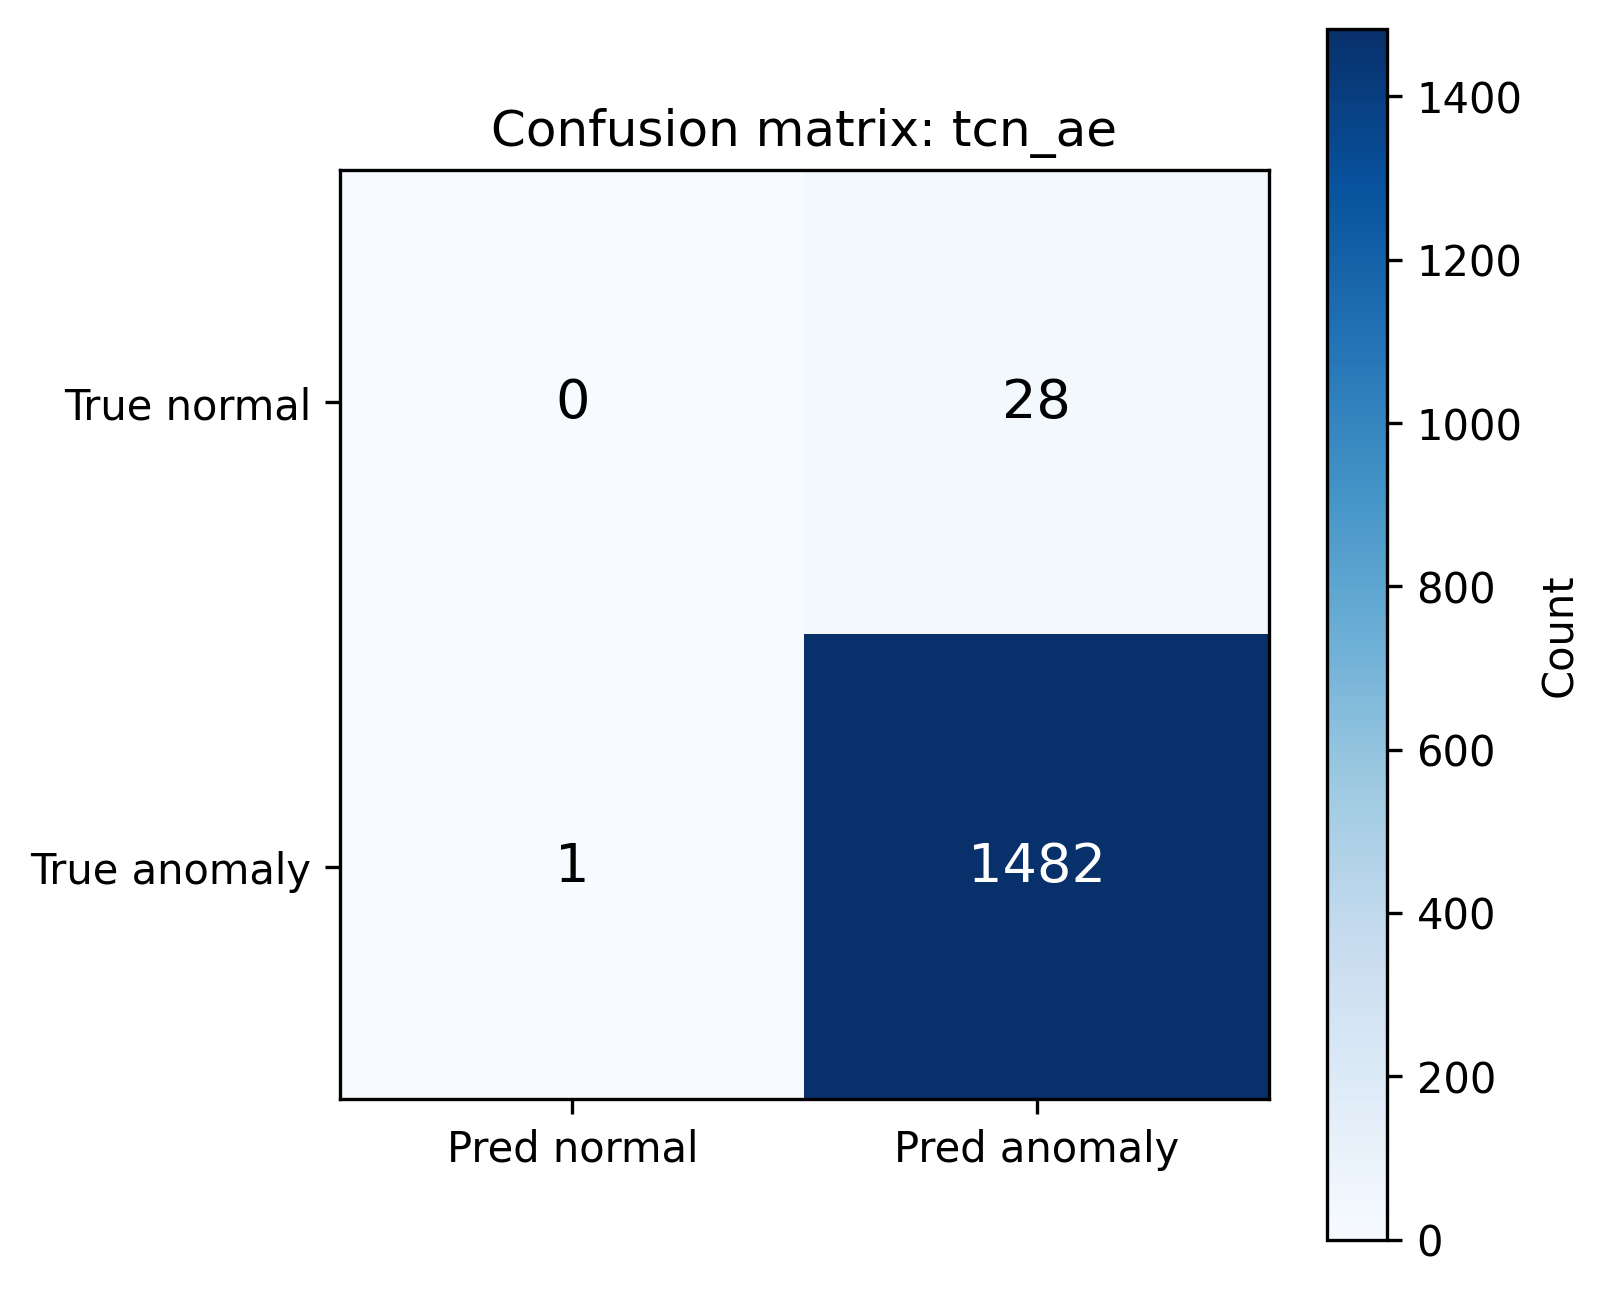

`confusion_matrix_tcn_transformer_ae.png`

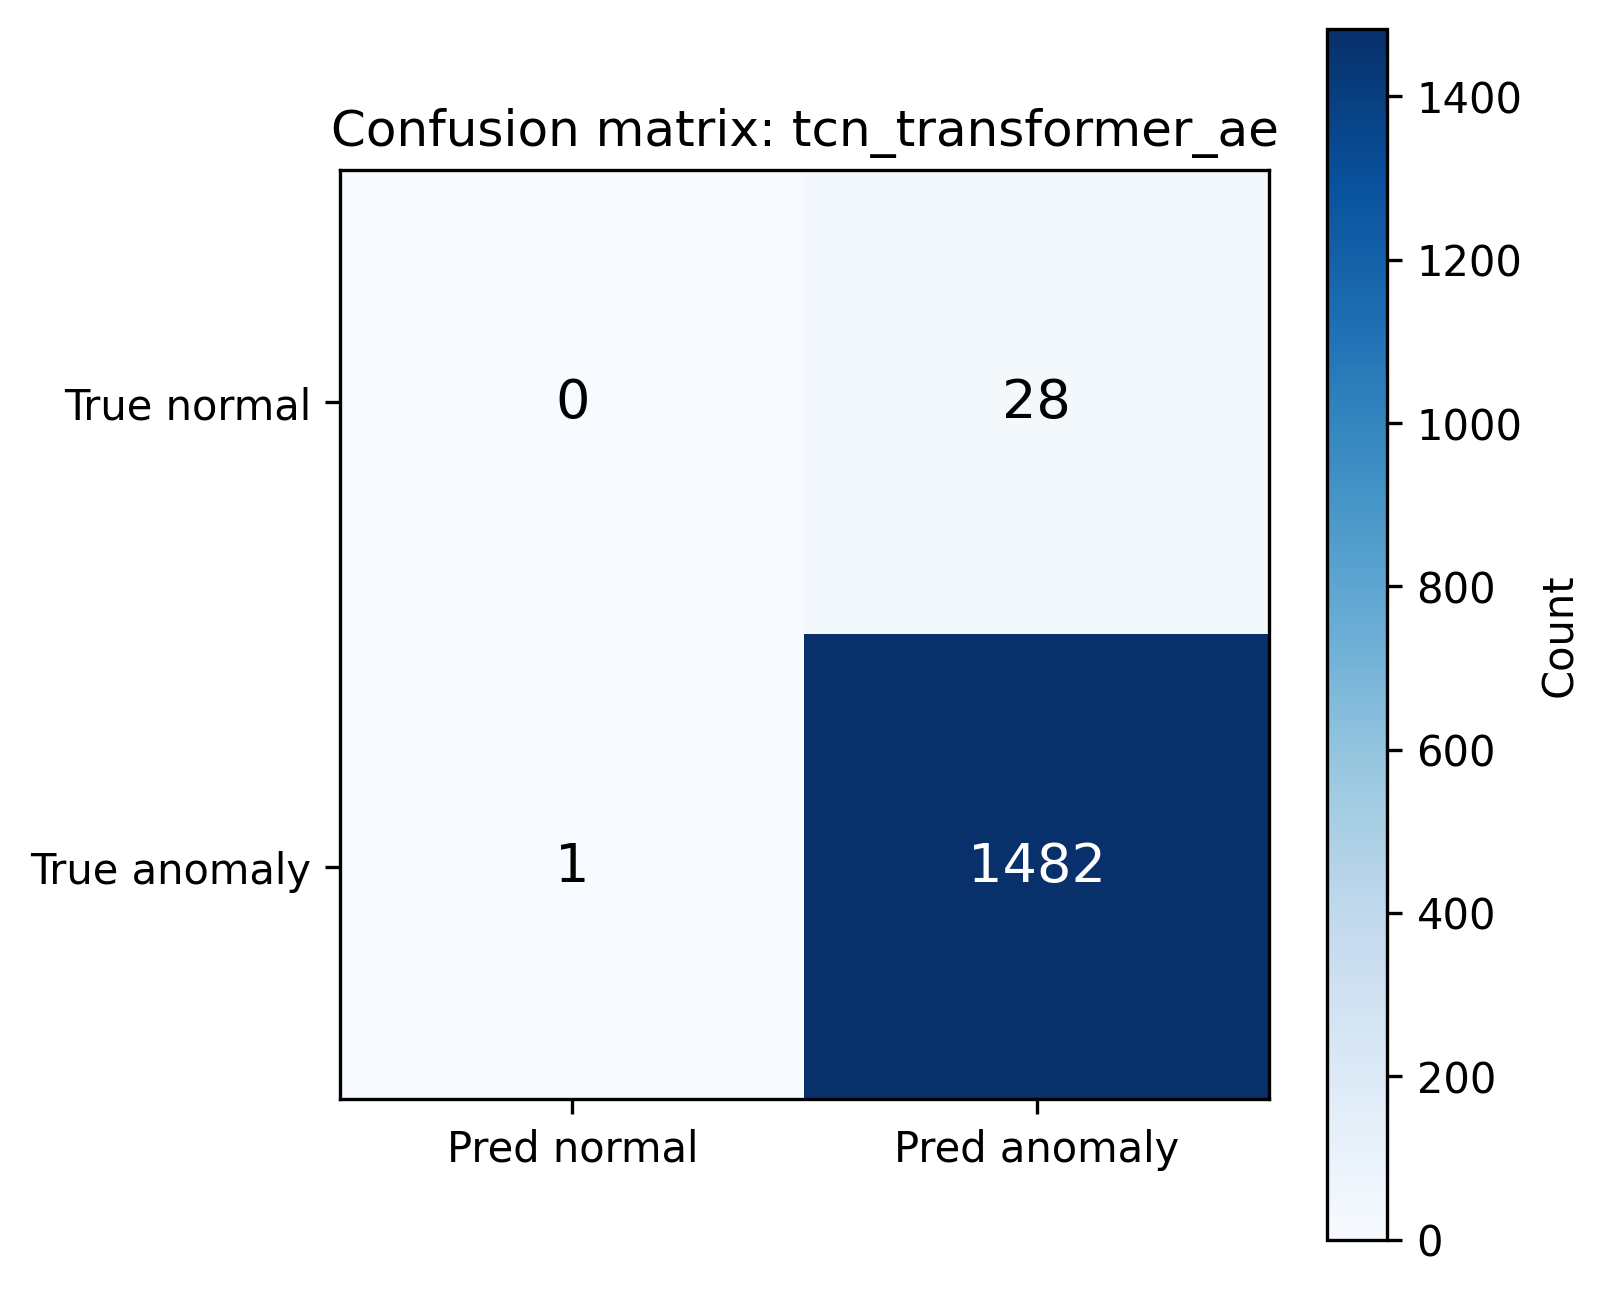

`confusion_matrix_tcn_transformer_ae_ensemble.png`

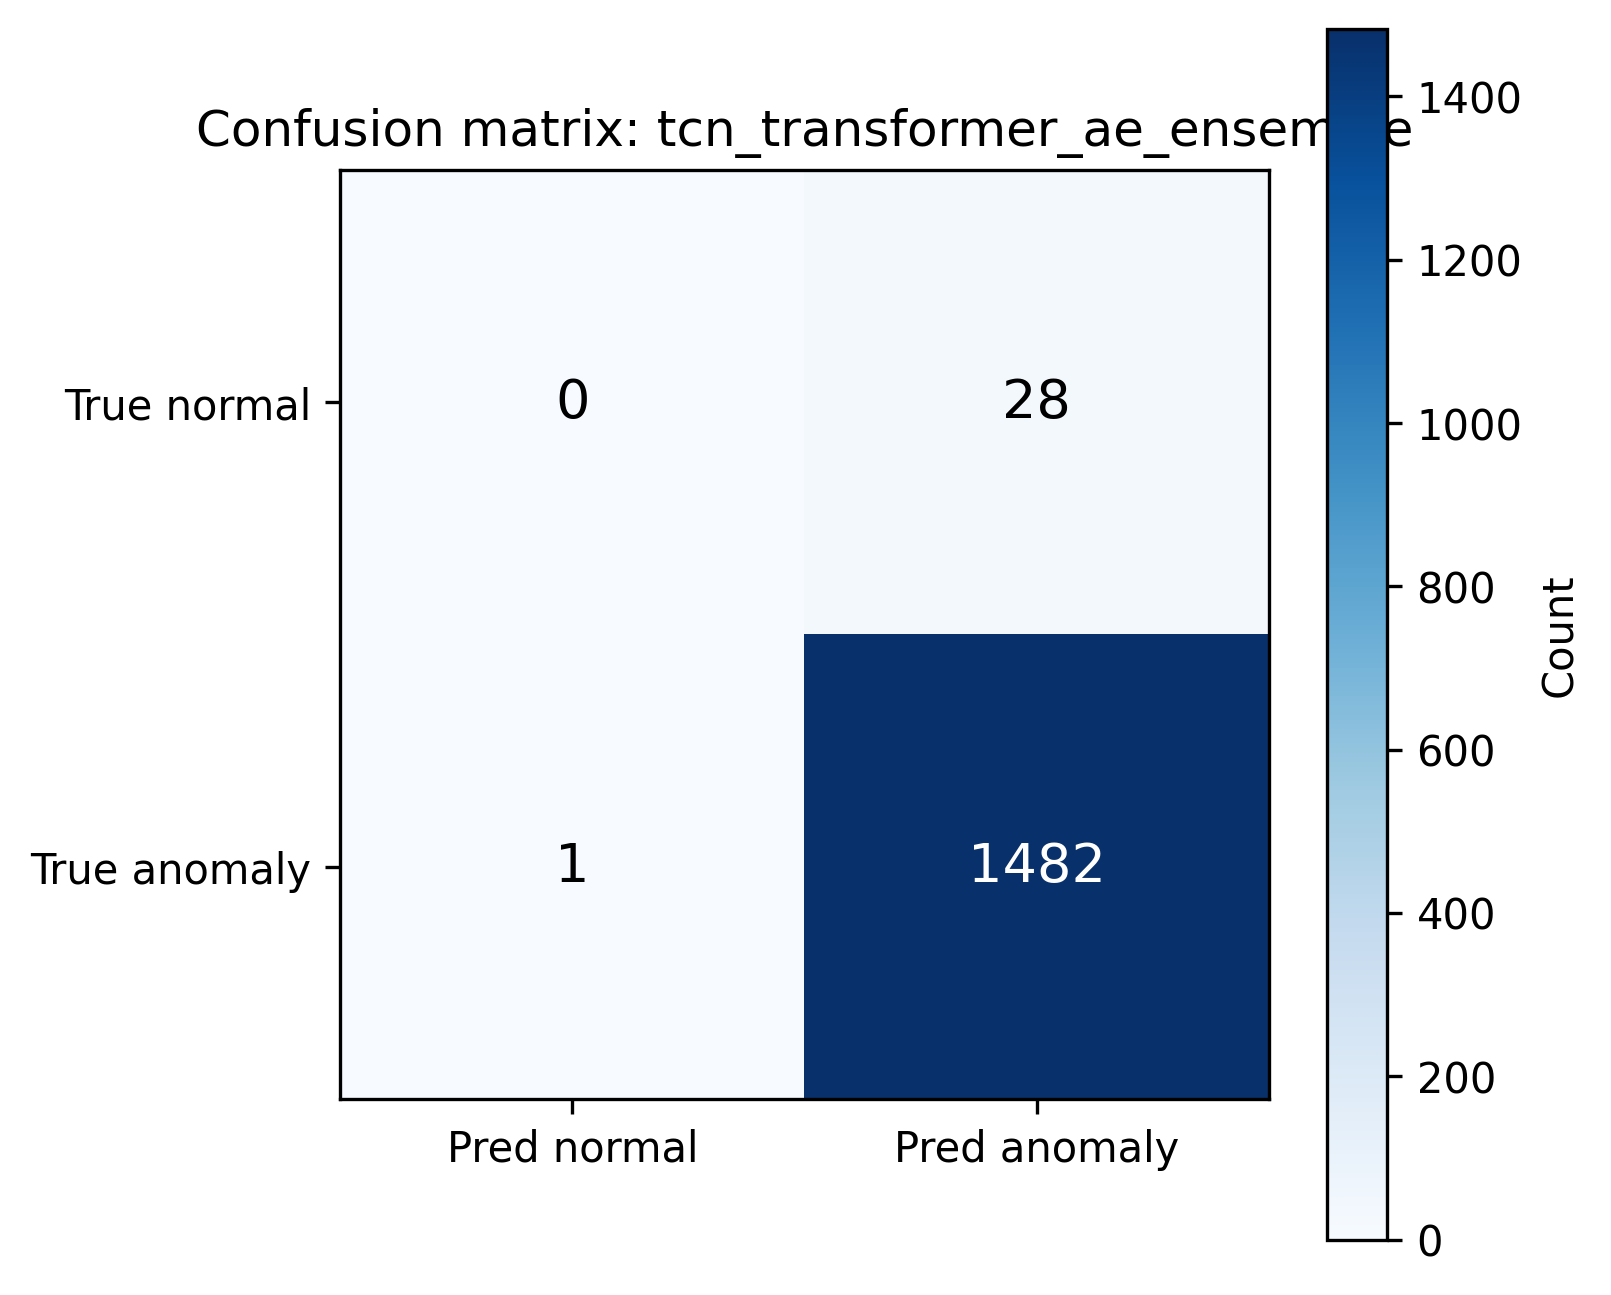

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

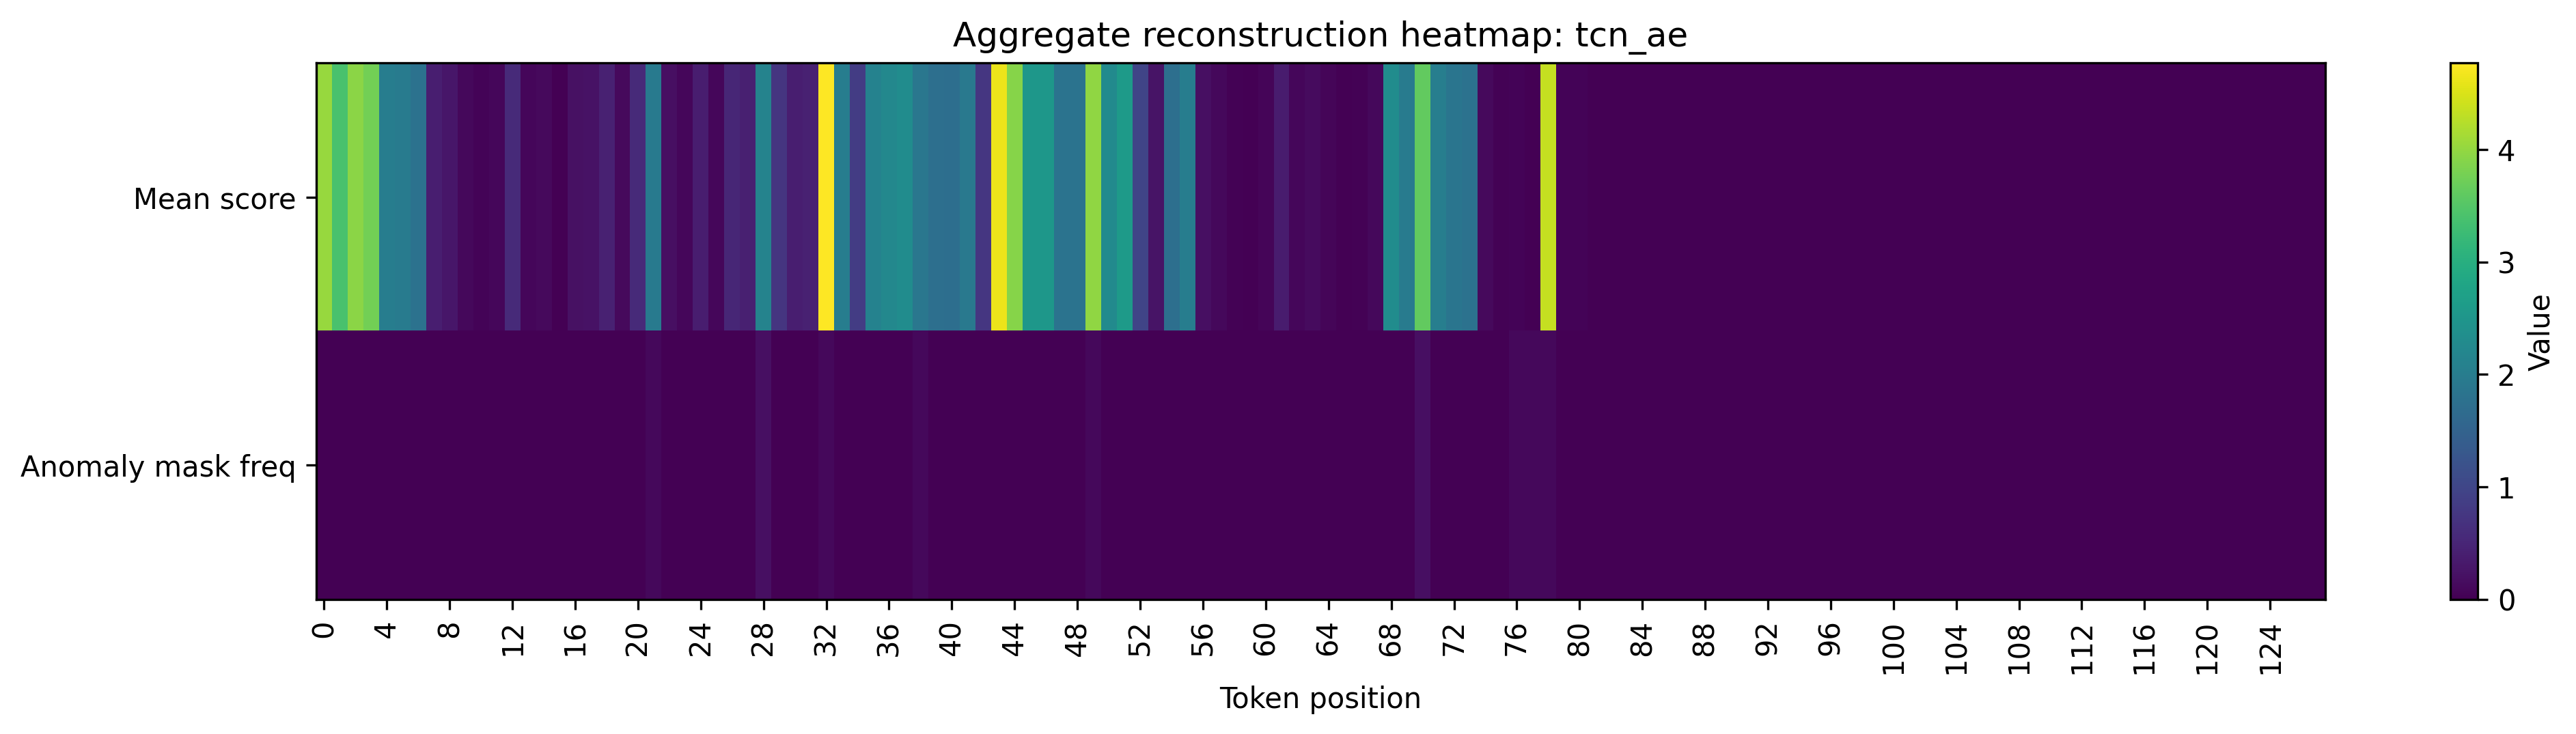

`aggregate_heatmap_tcn_transformer_ae_attention.png`

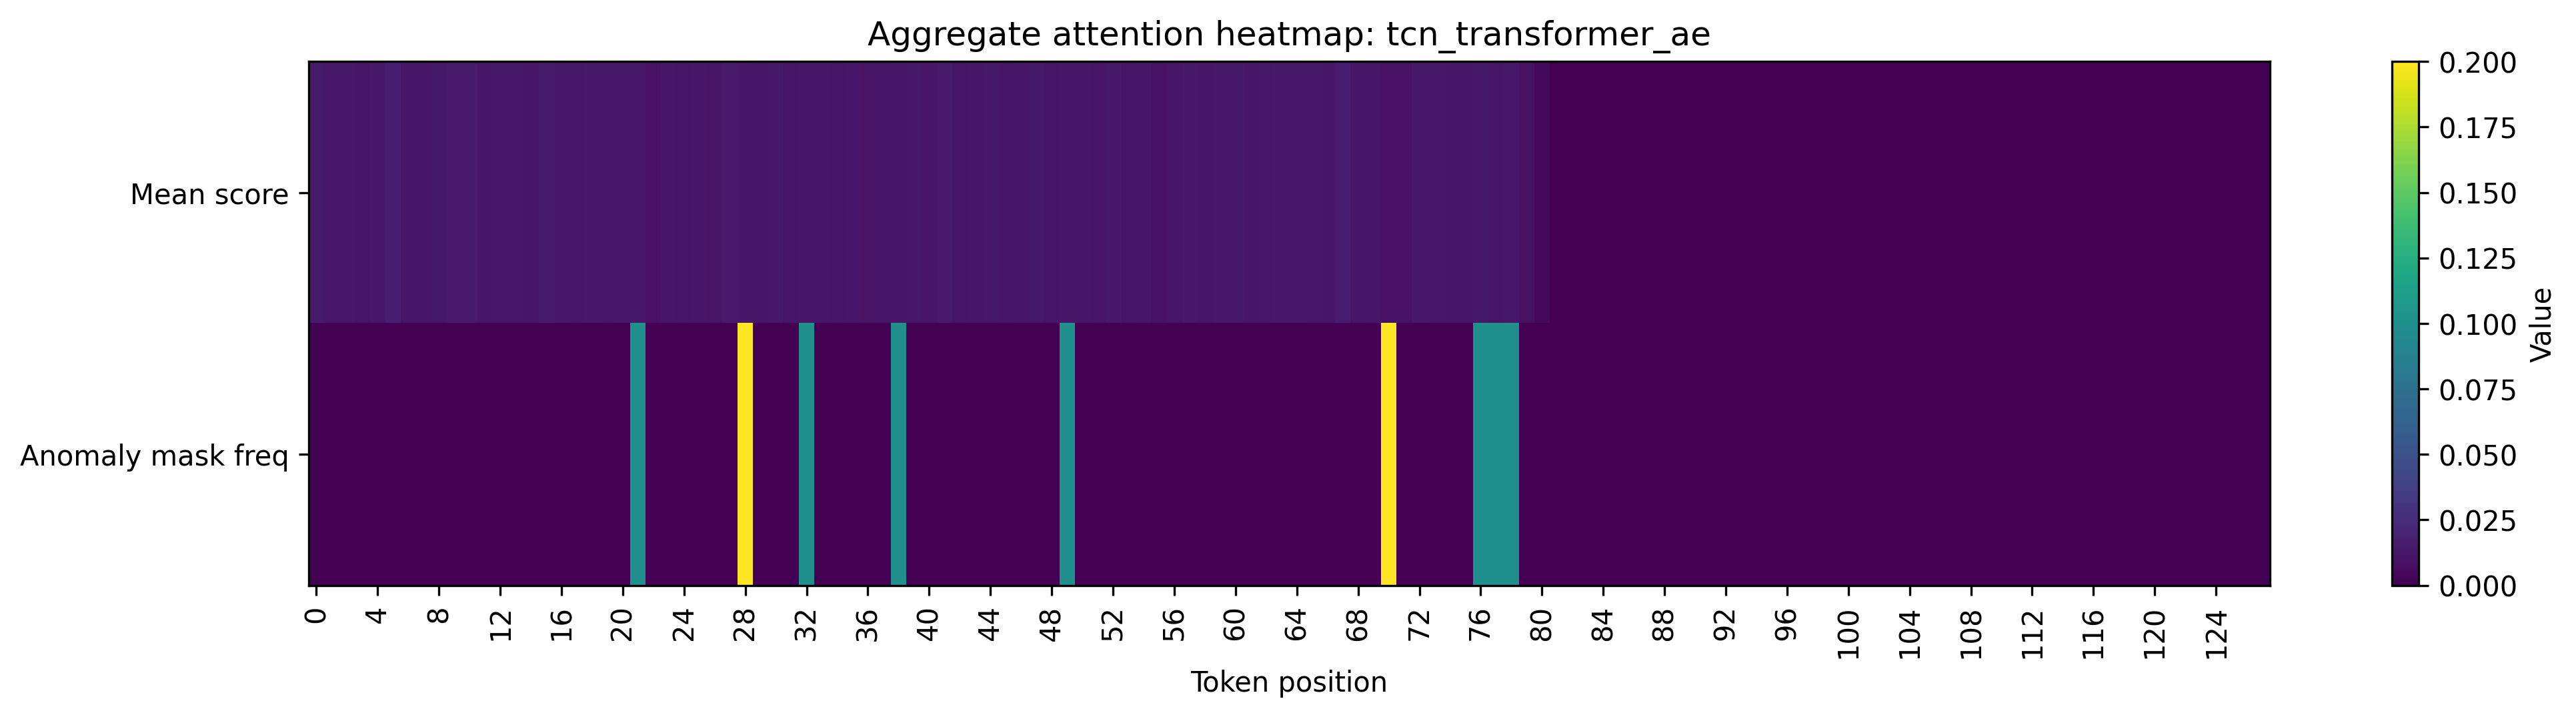

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

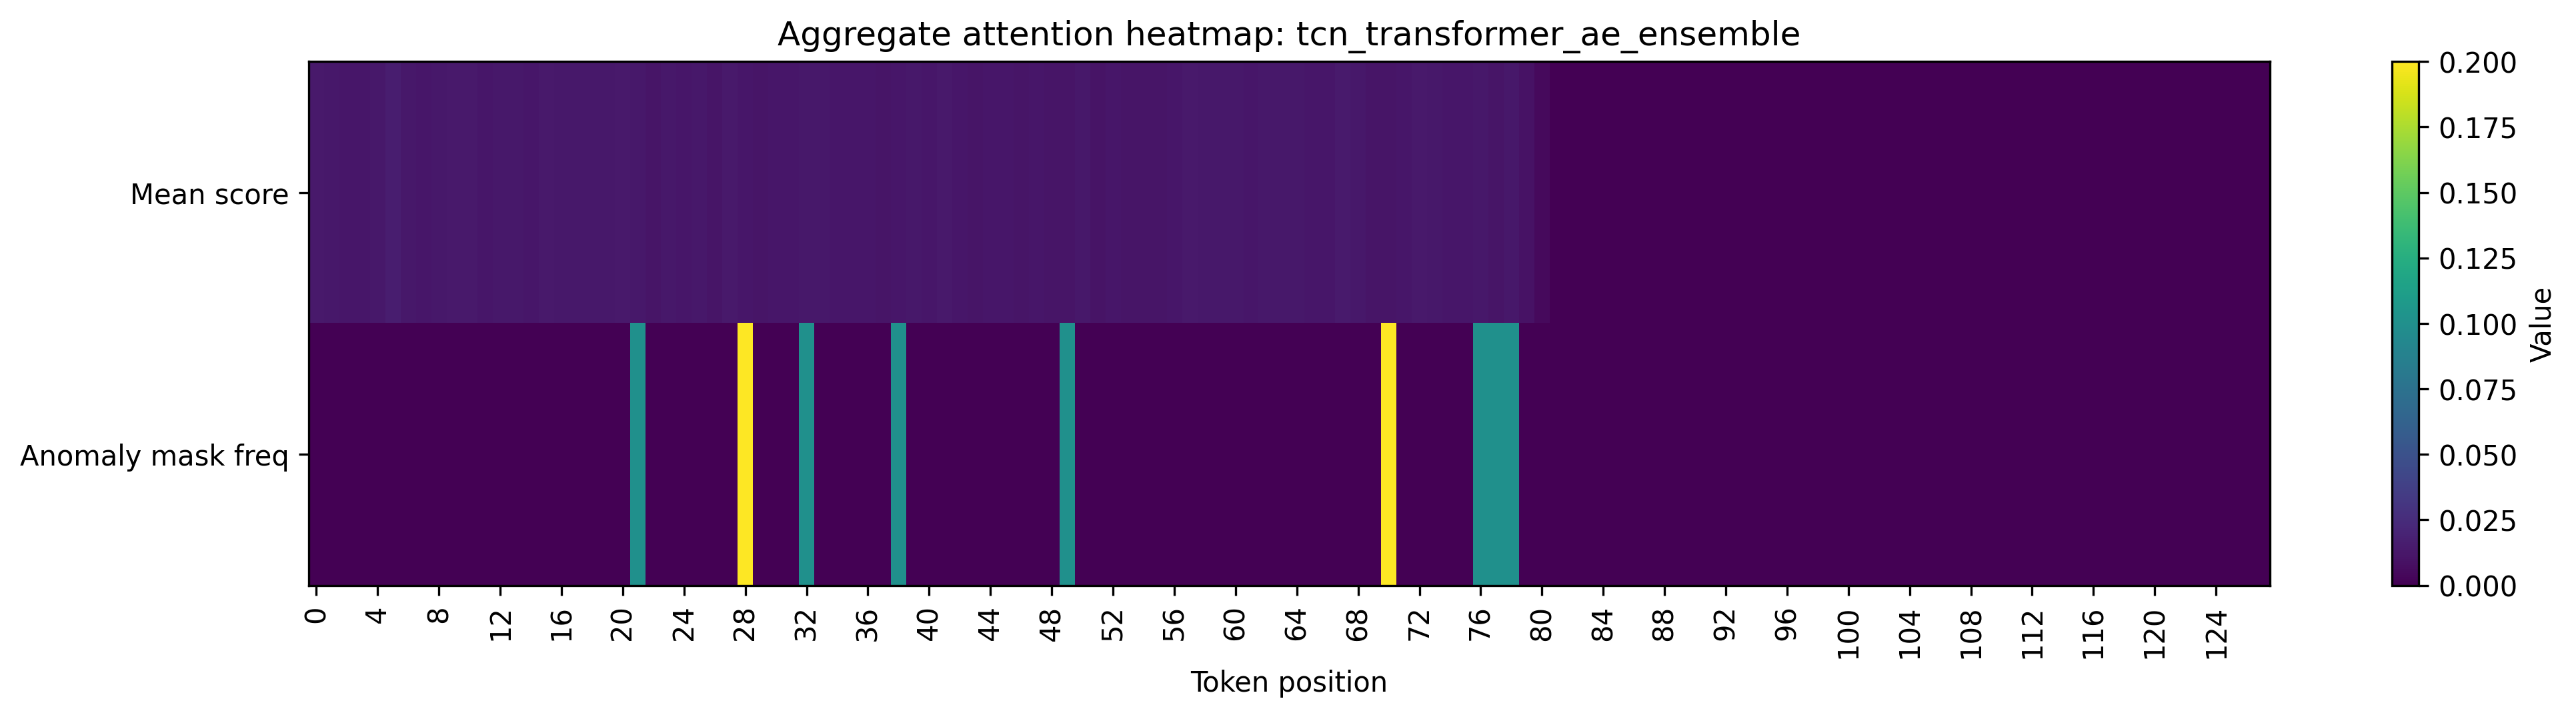

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

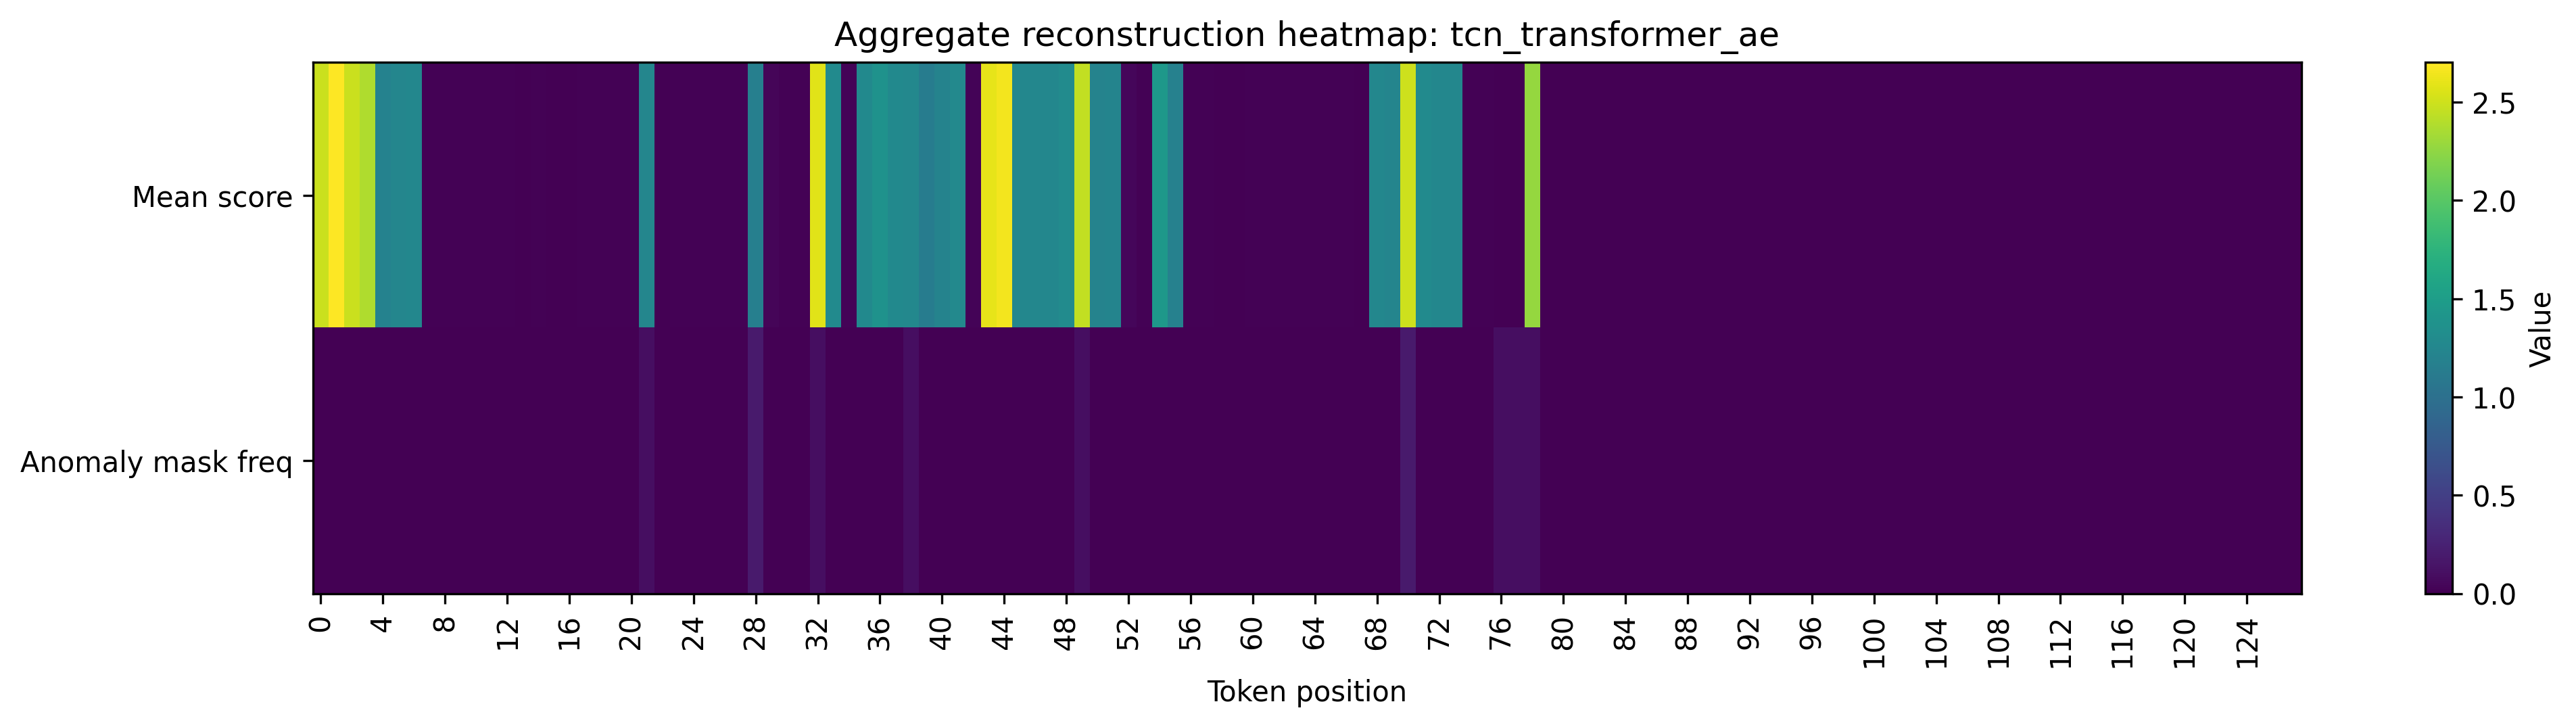

### loghub2

**Матрицы ошибок**

`confusion_matrix_tcn_ae.png`

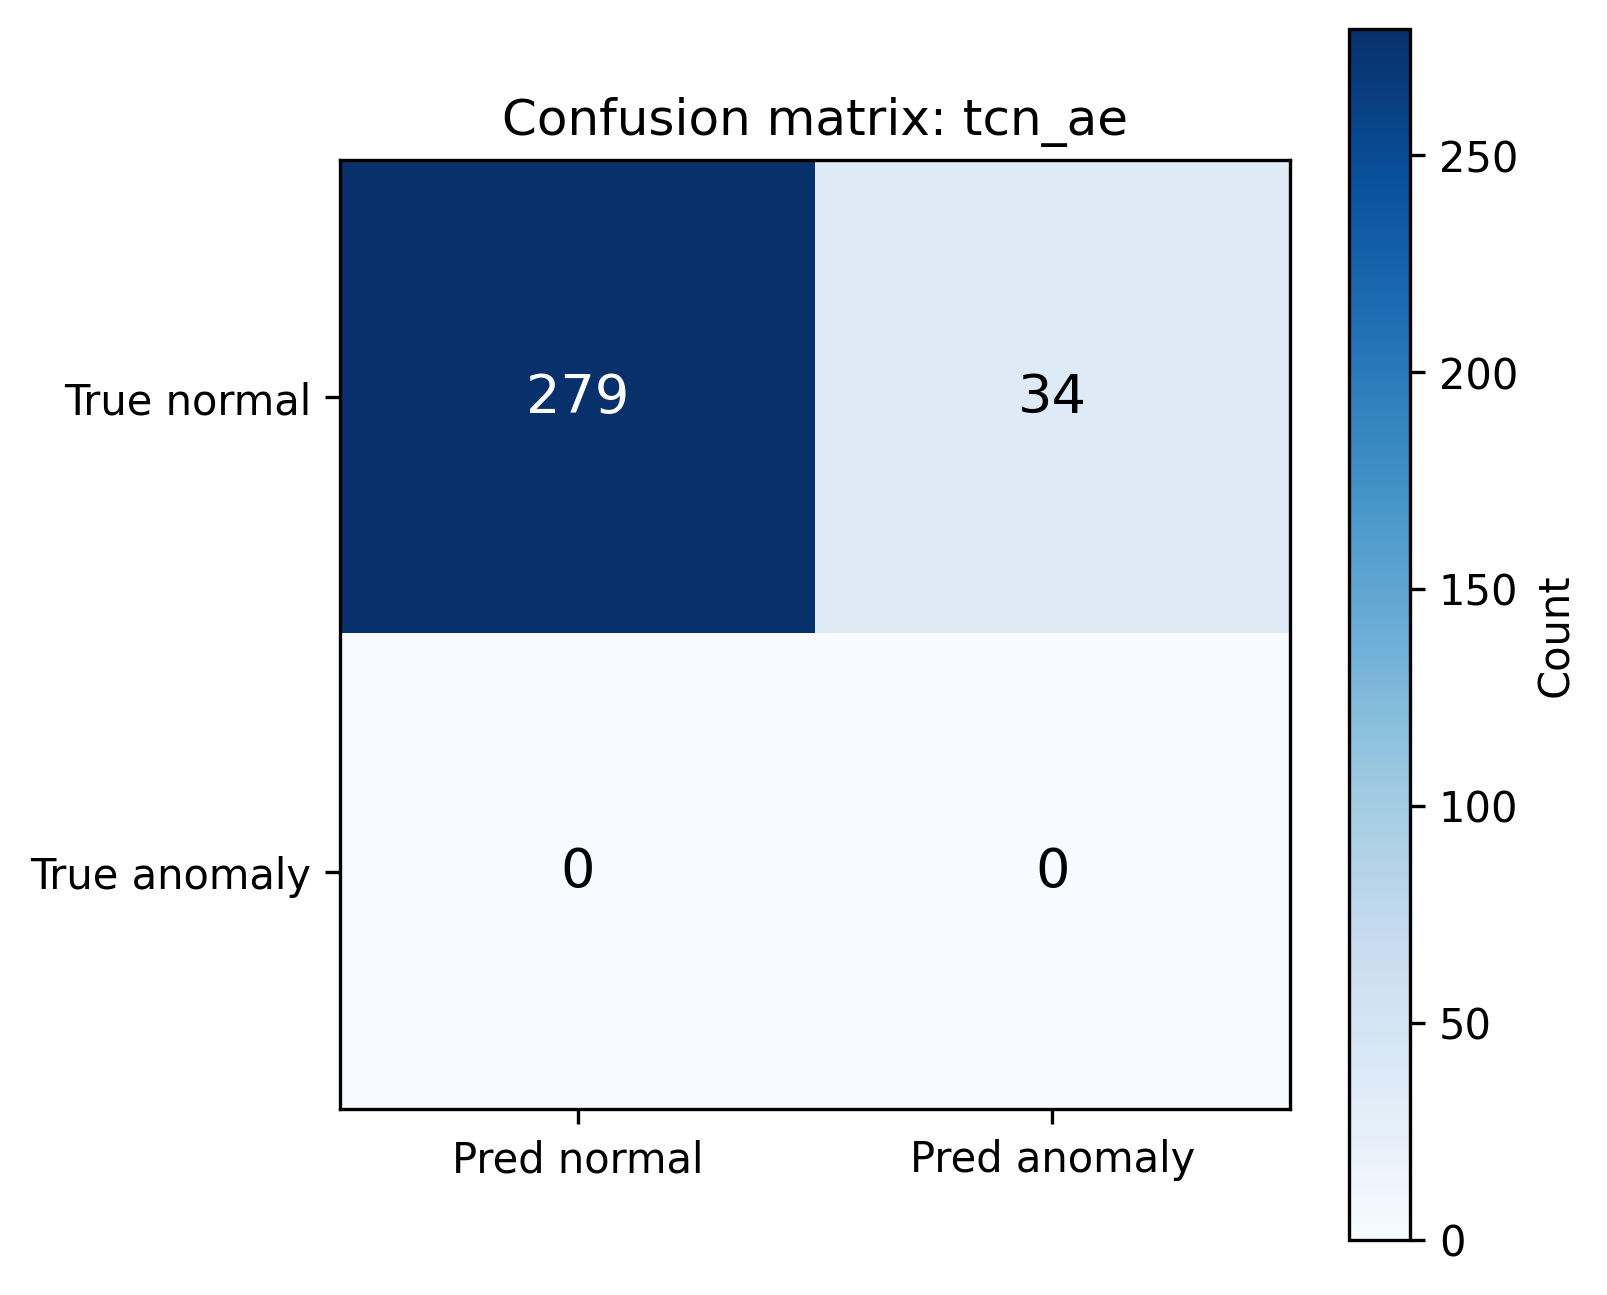

`confusion_matrix_tcn_transformer_ae.png`

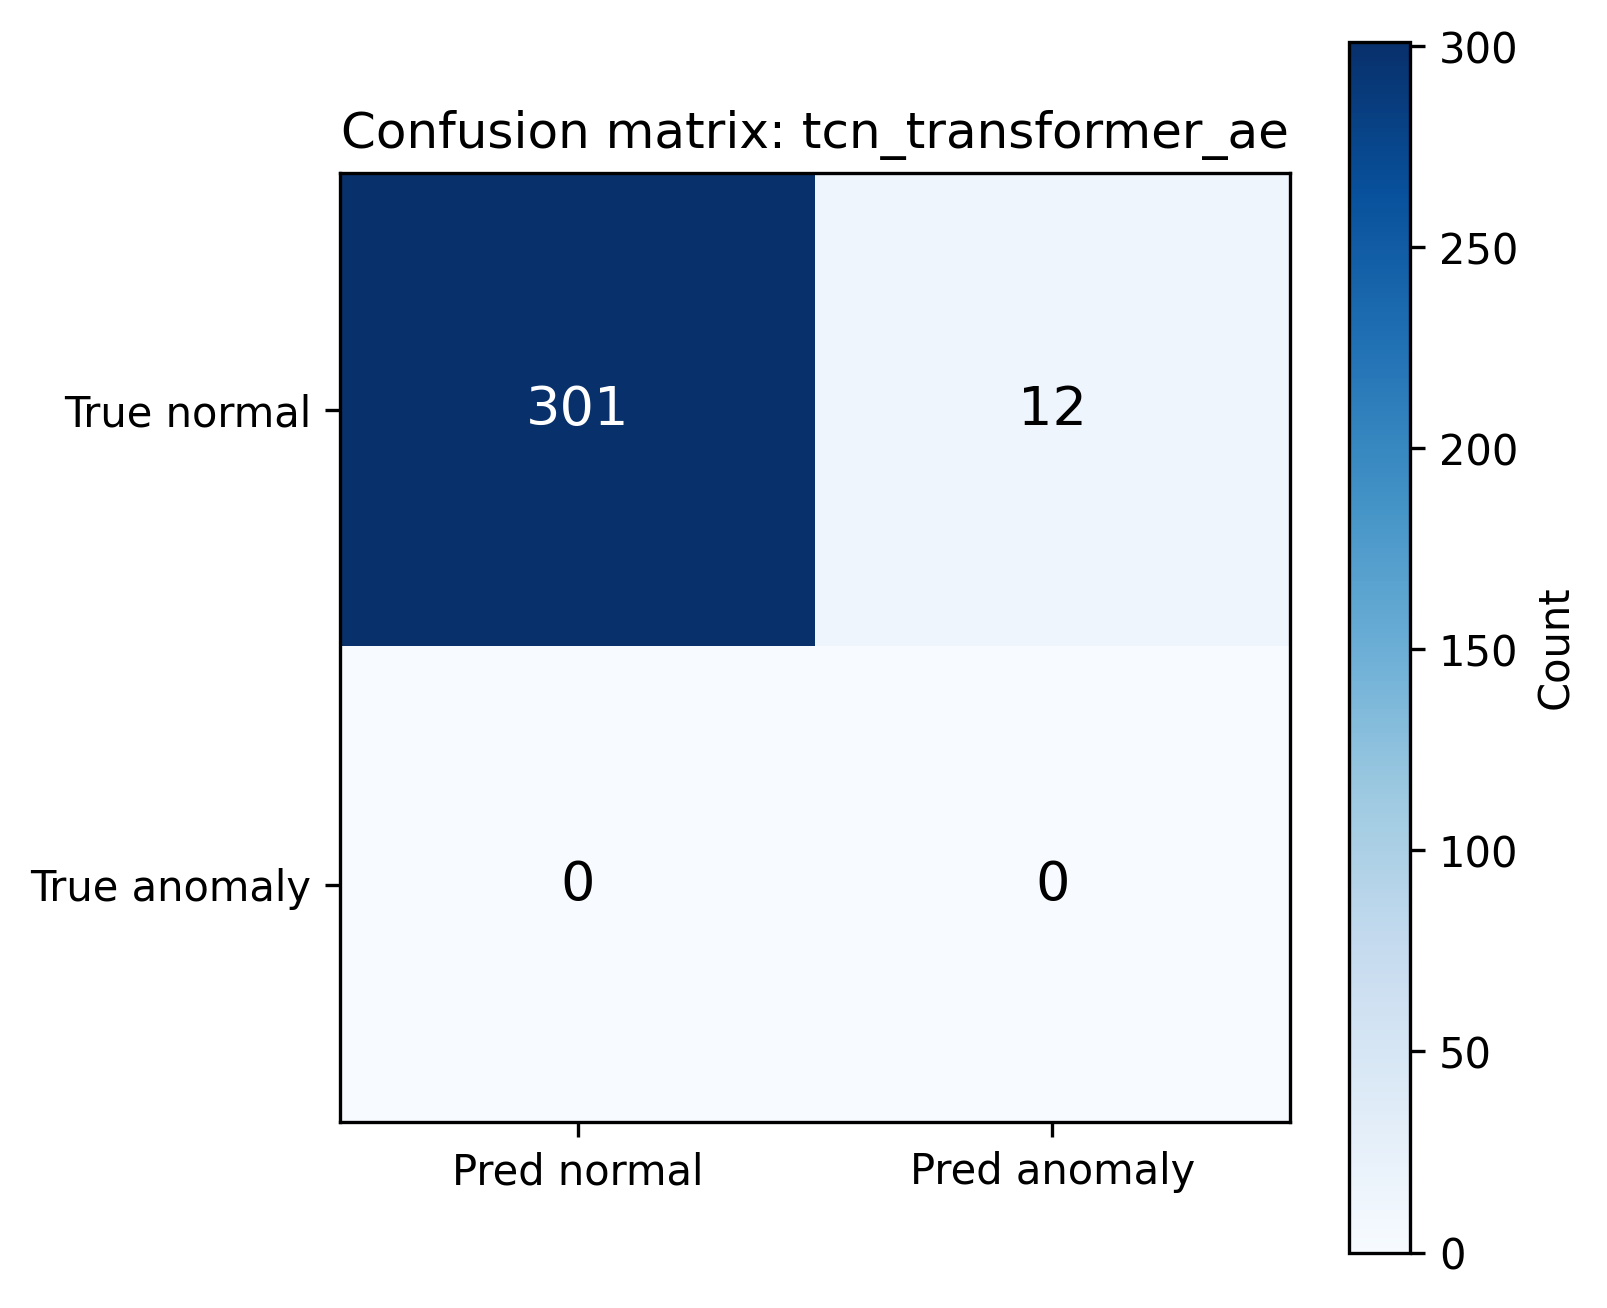

`confusion_matrix_tcn_transformer_ae_ensemble.png`

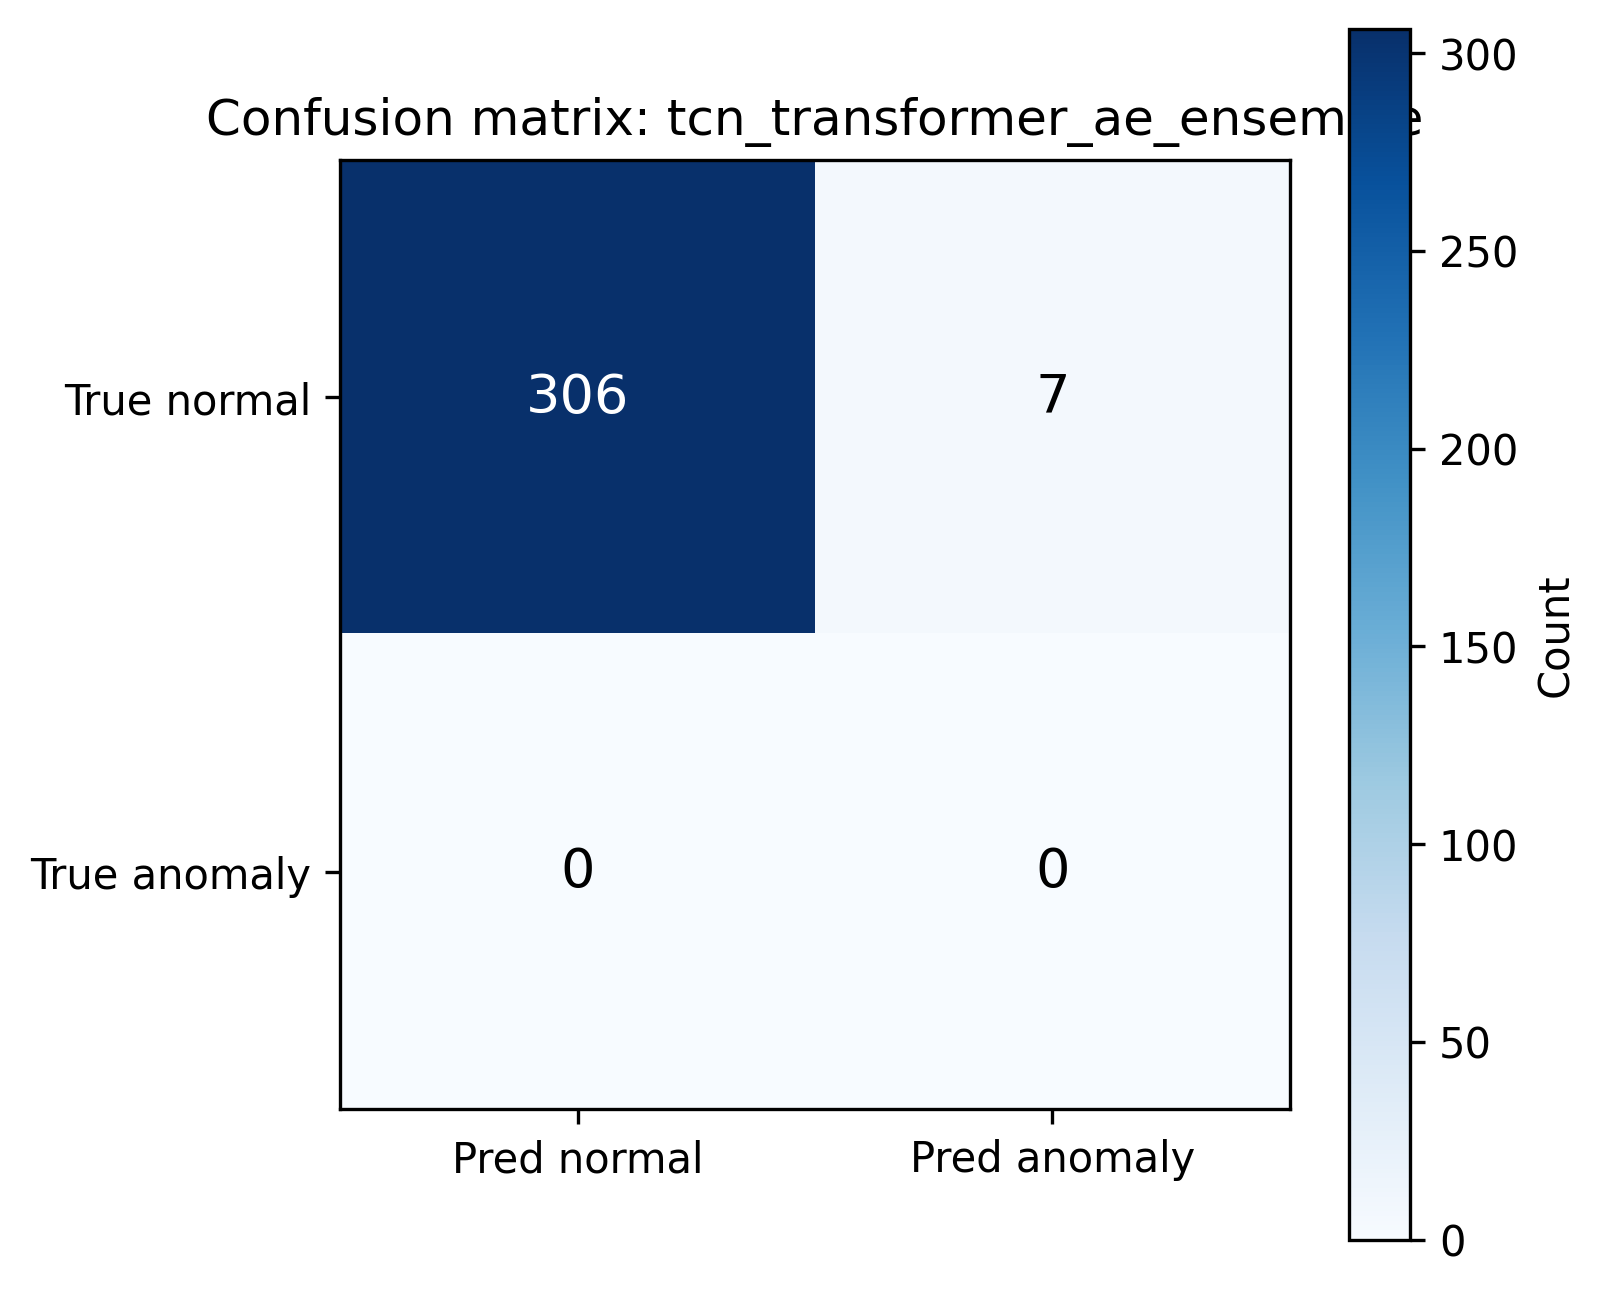

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

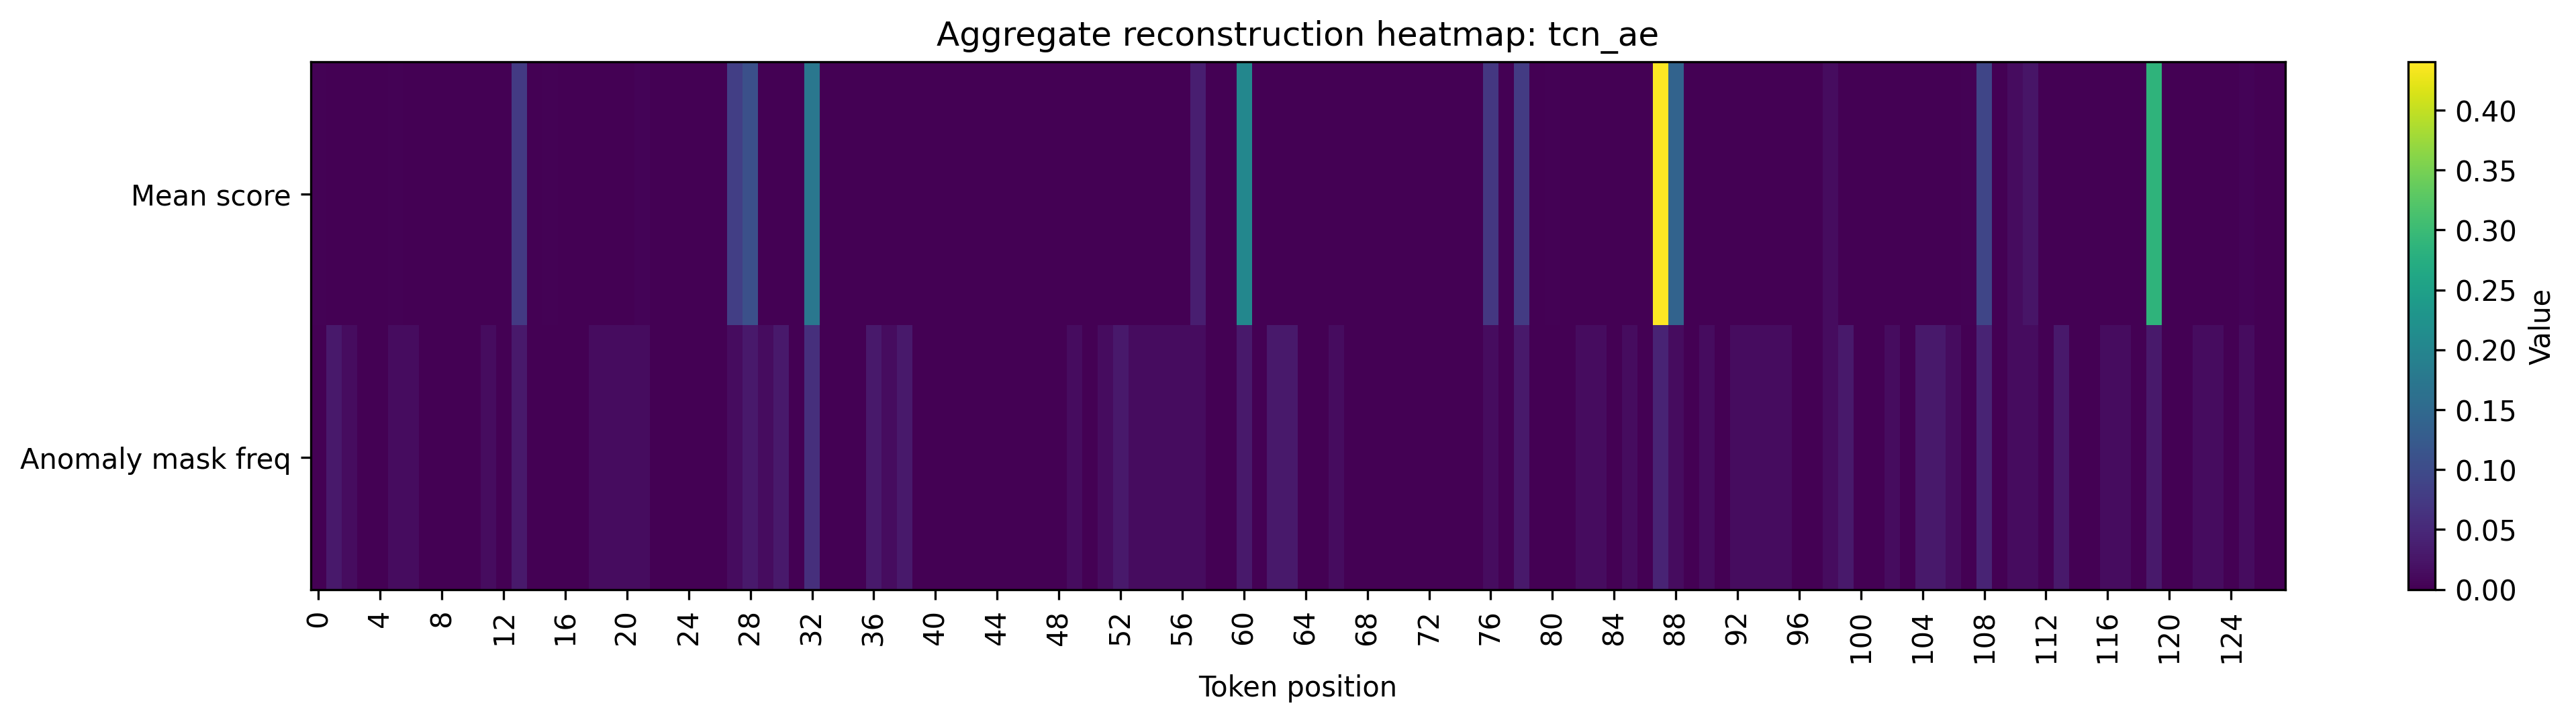

`aggregate_heatmap_tcn_transformer_ae_attention.png`

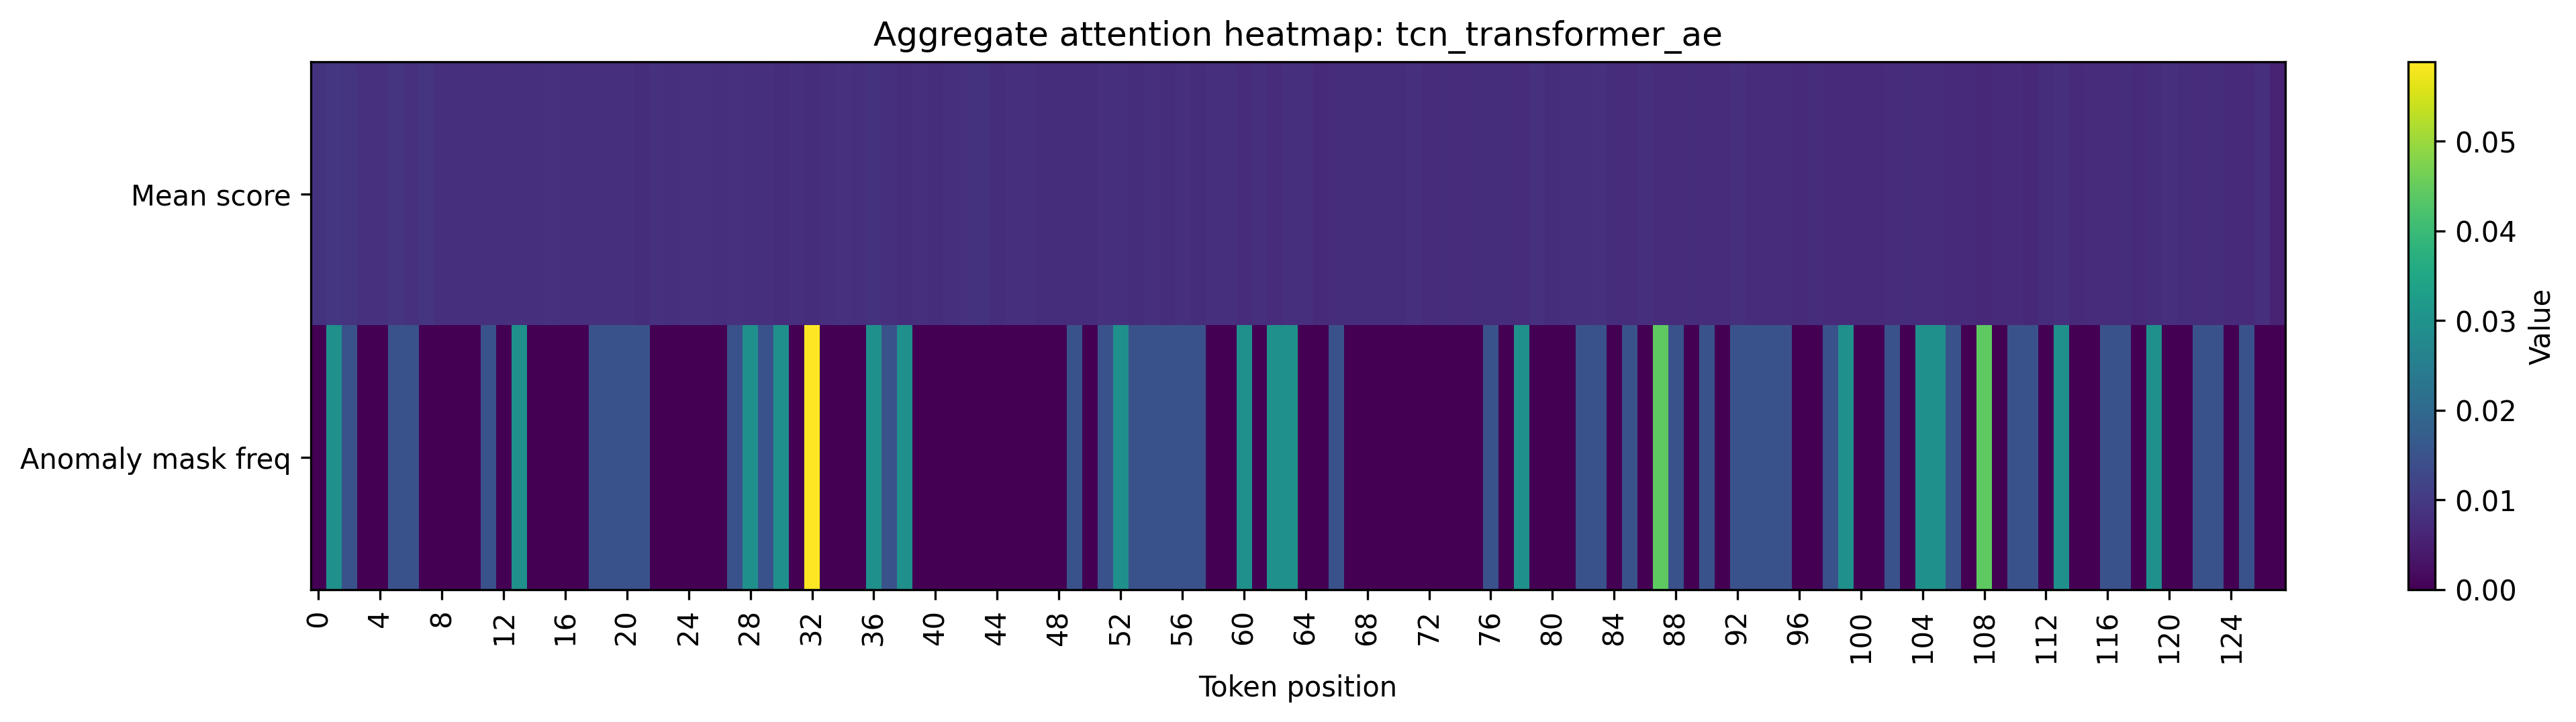

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

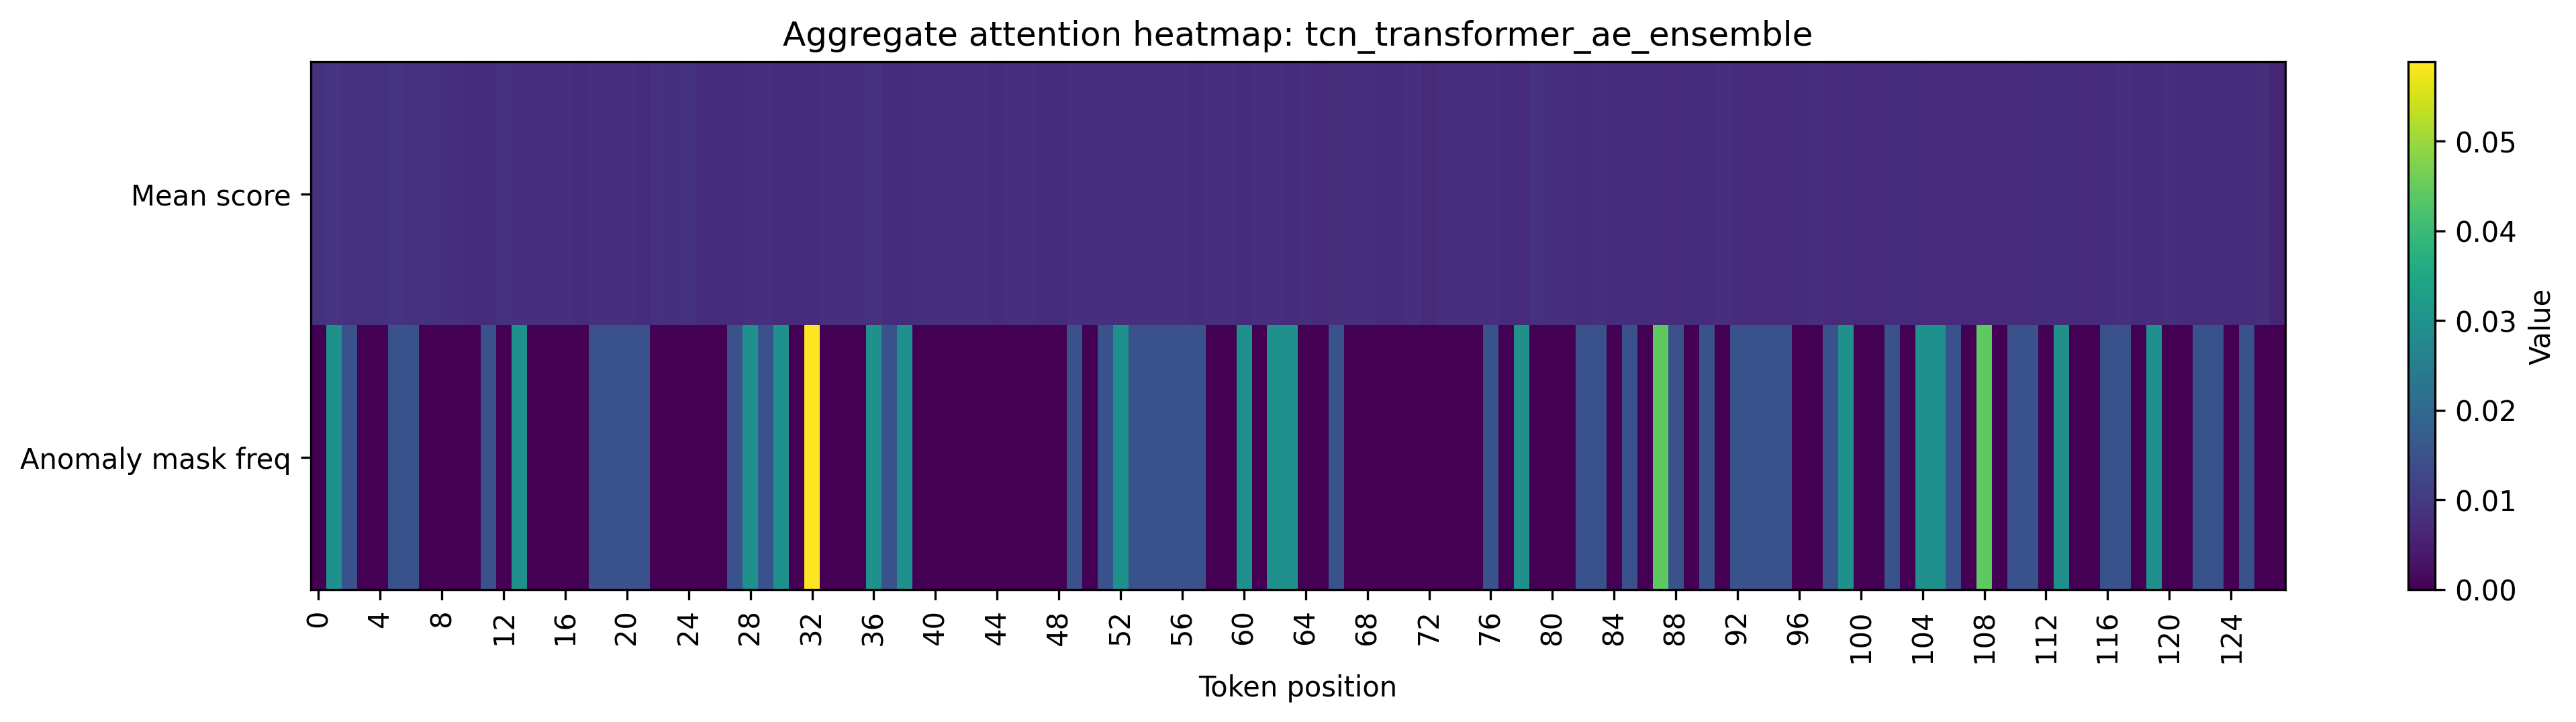

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

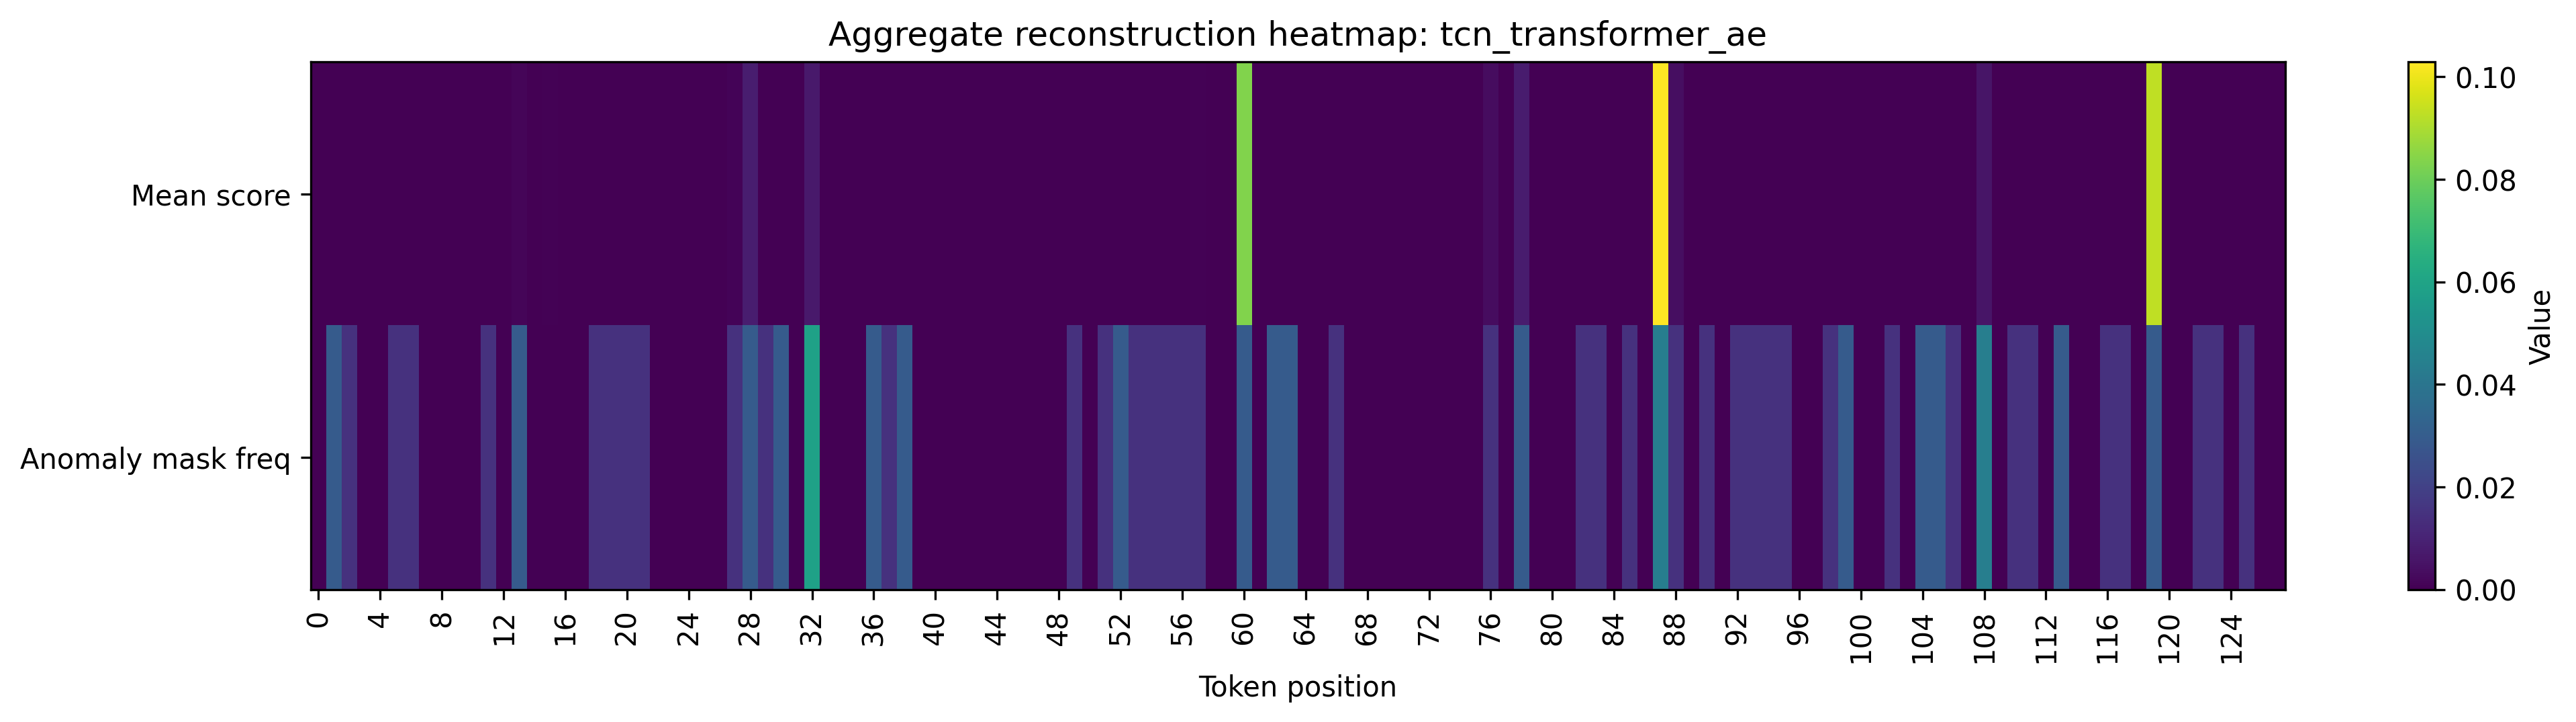

### rcaeval

**Матрицы ошибок**

`confusion_matrix_tcn_ae.png`

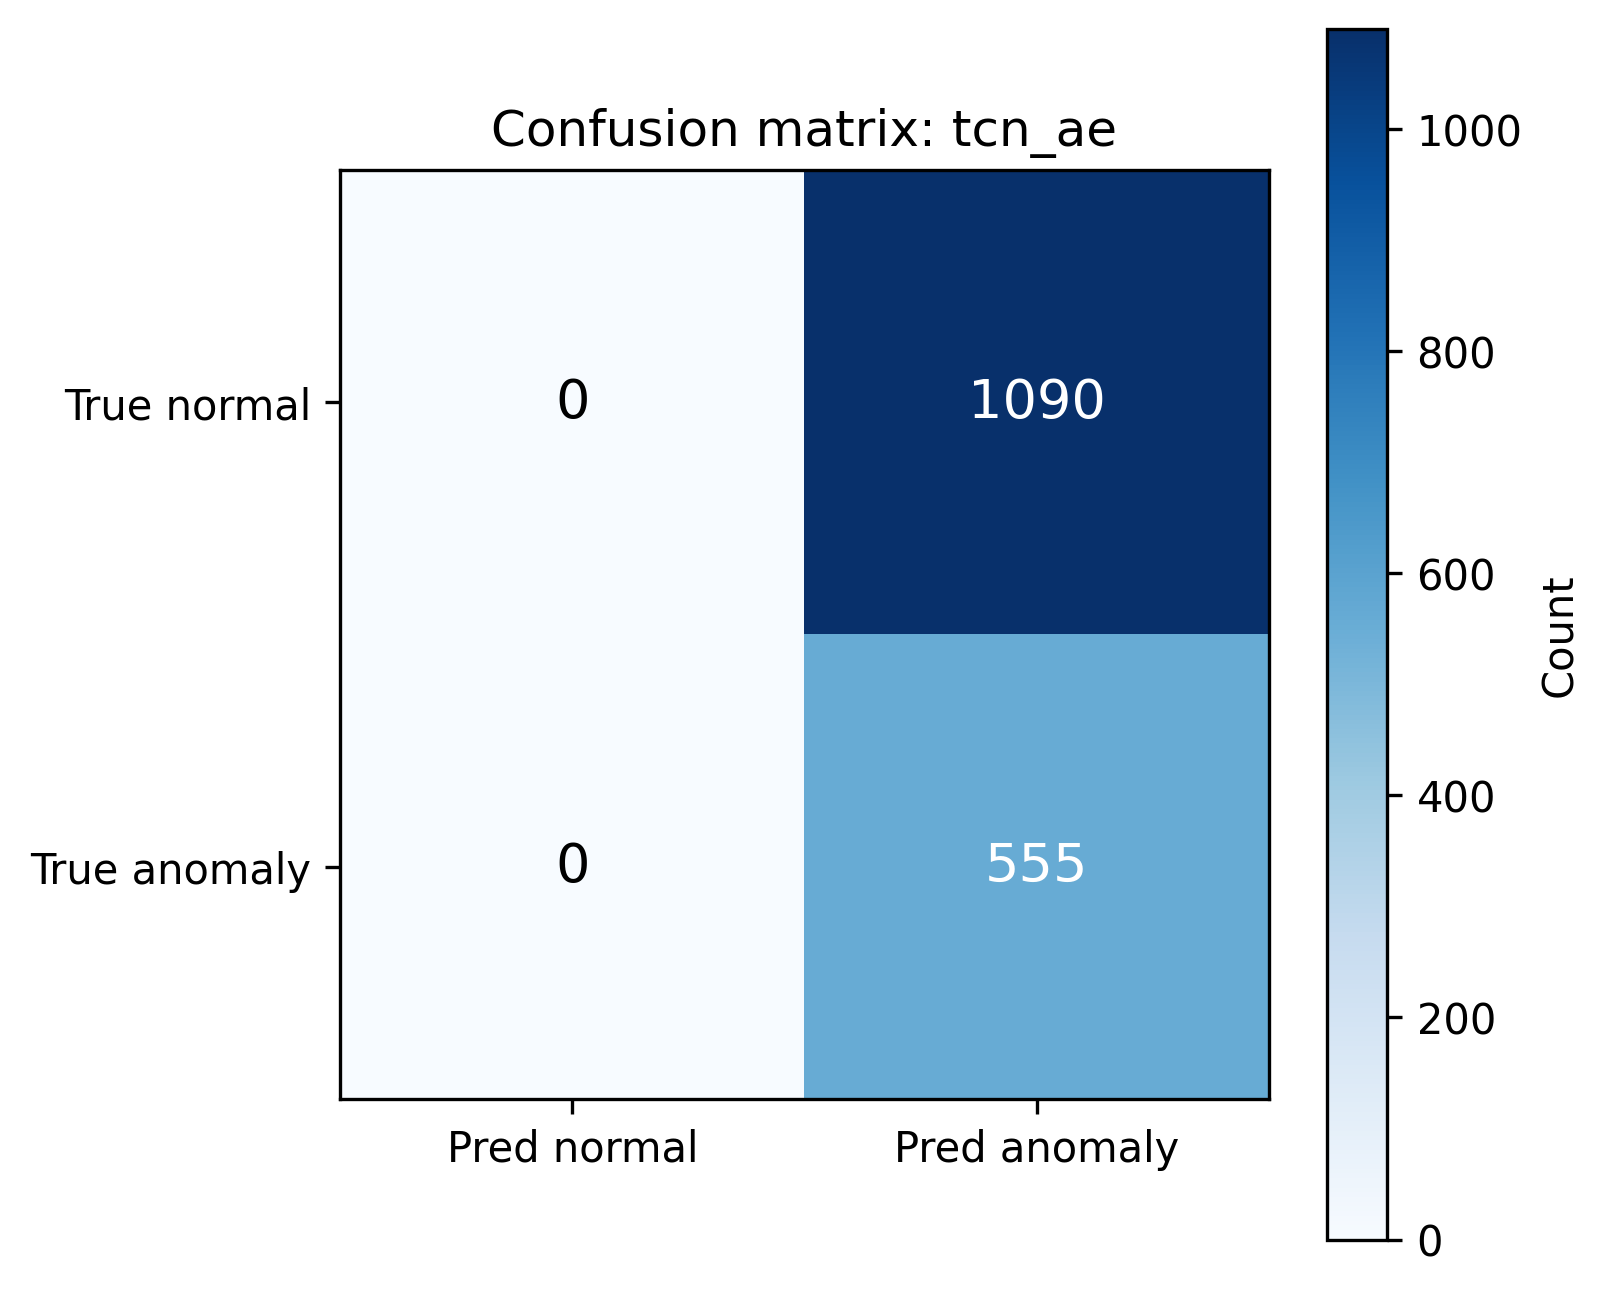

`confusion_matrix_tcn_transformer_ae.png`

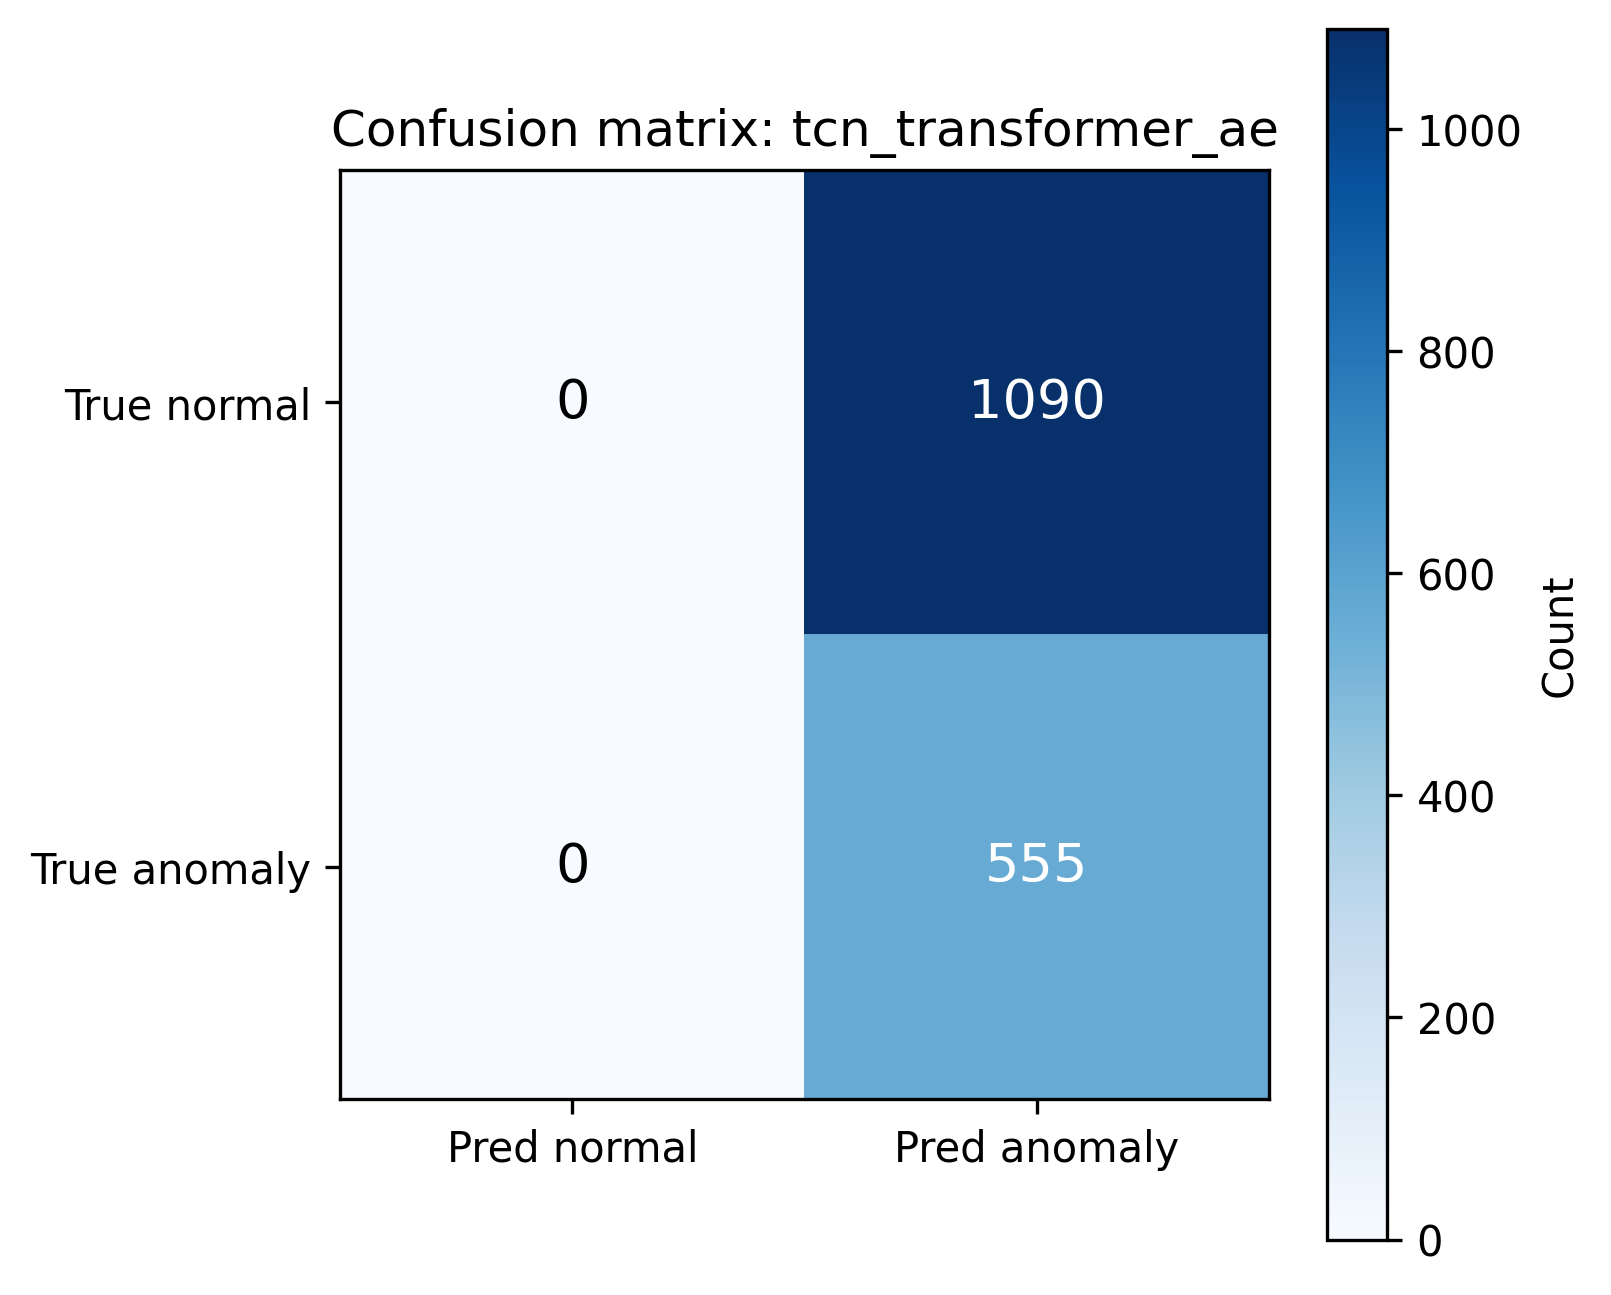

`confusion_matrix_tcn_transformer_ae_ensemble.png`

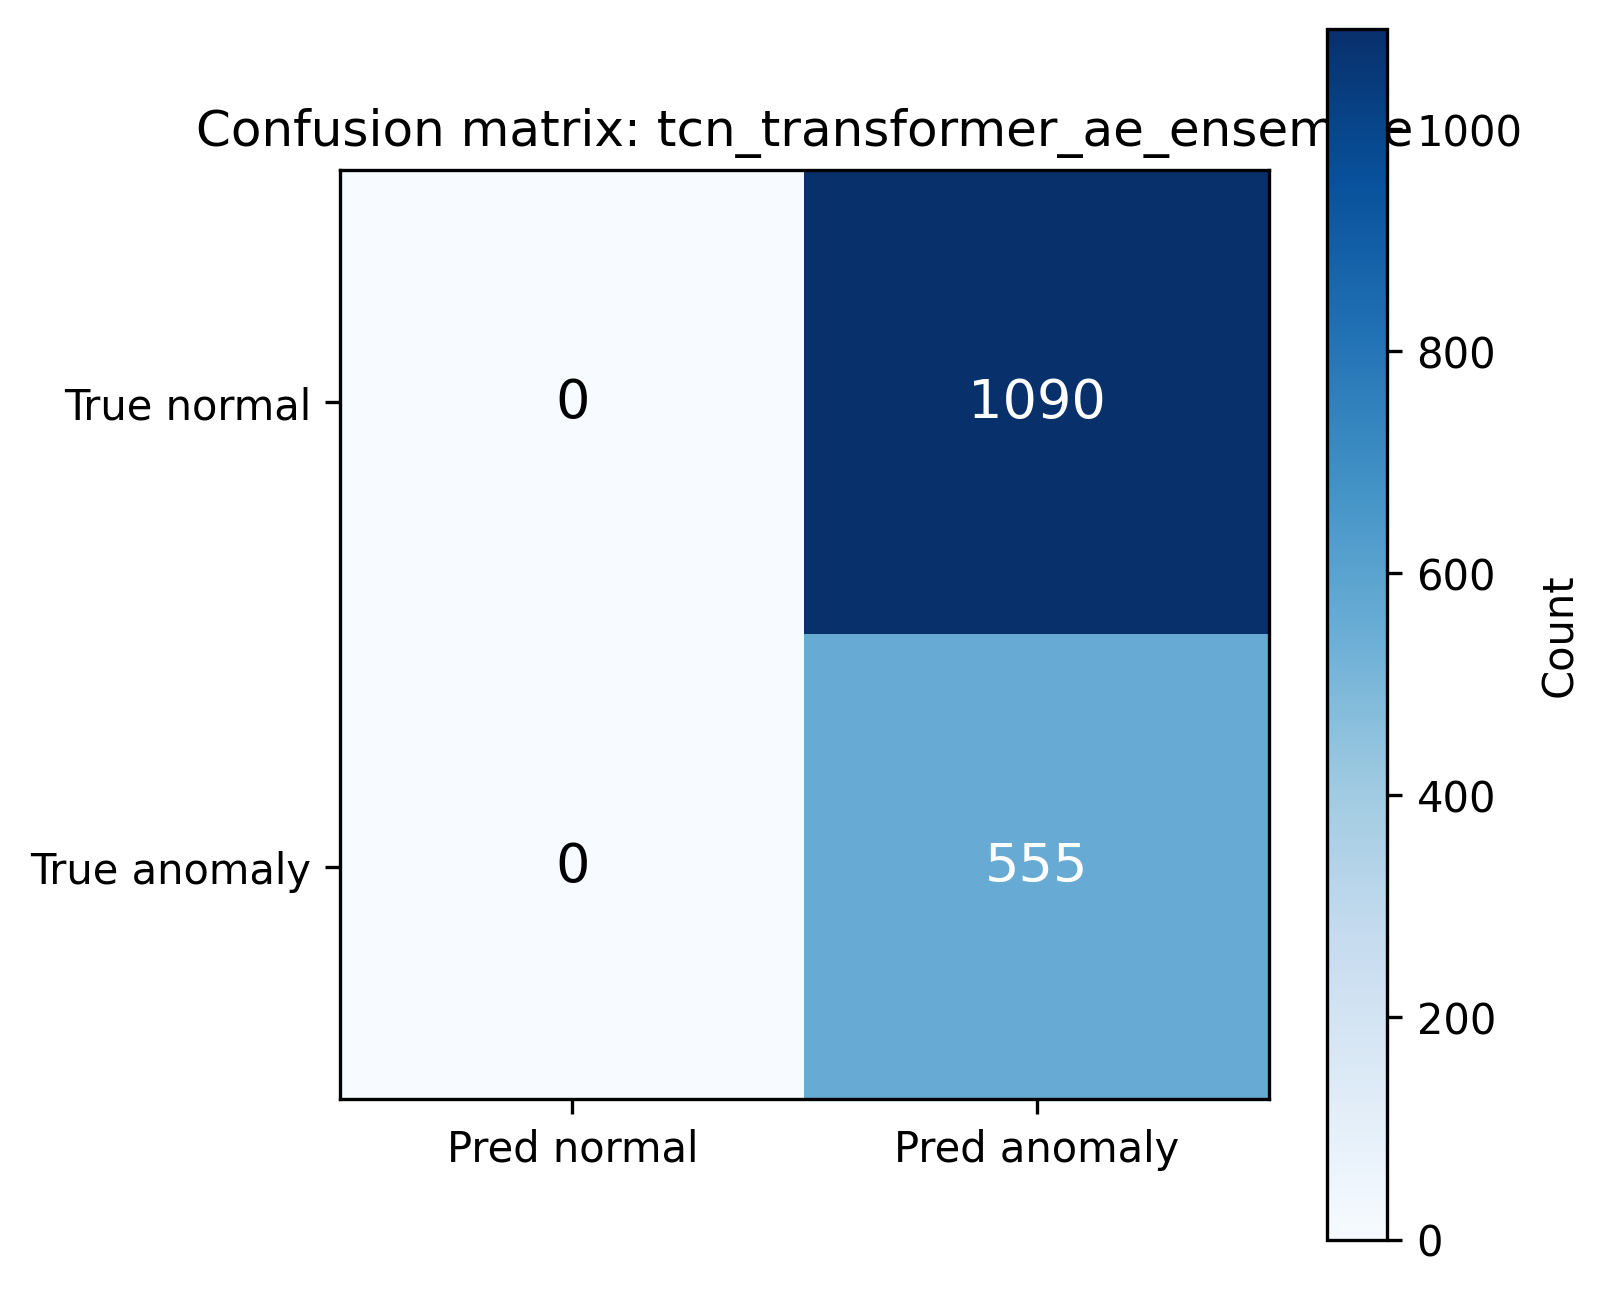

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

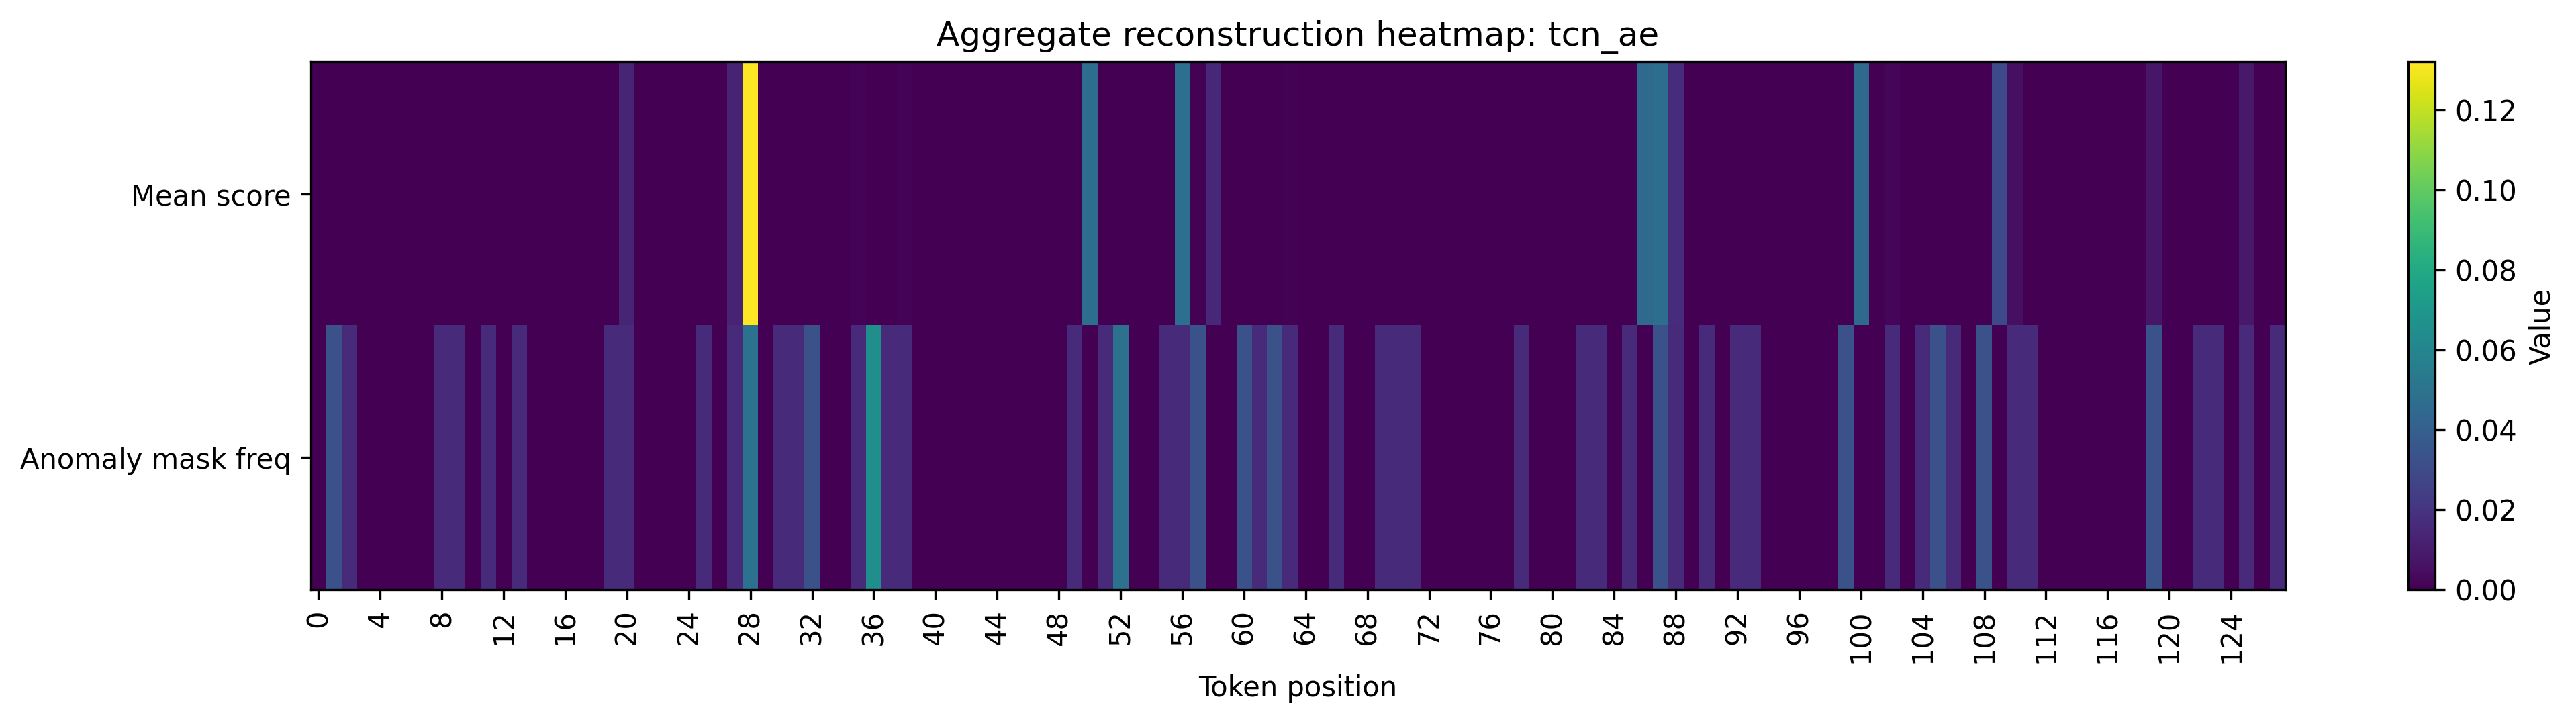

`aggregate_heatmap_tcn_transformer_ae_attention.png`

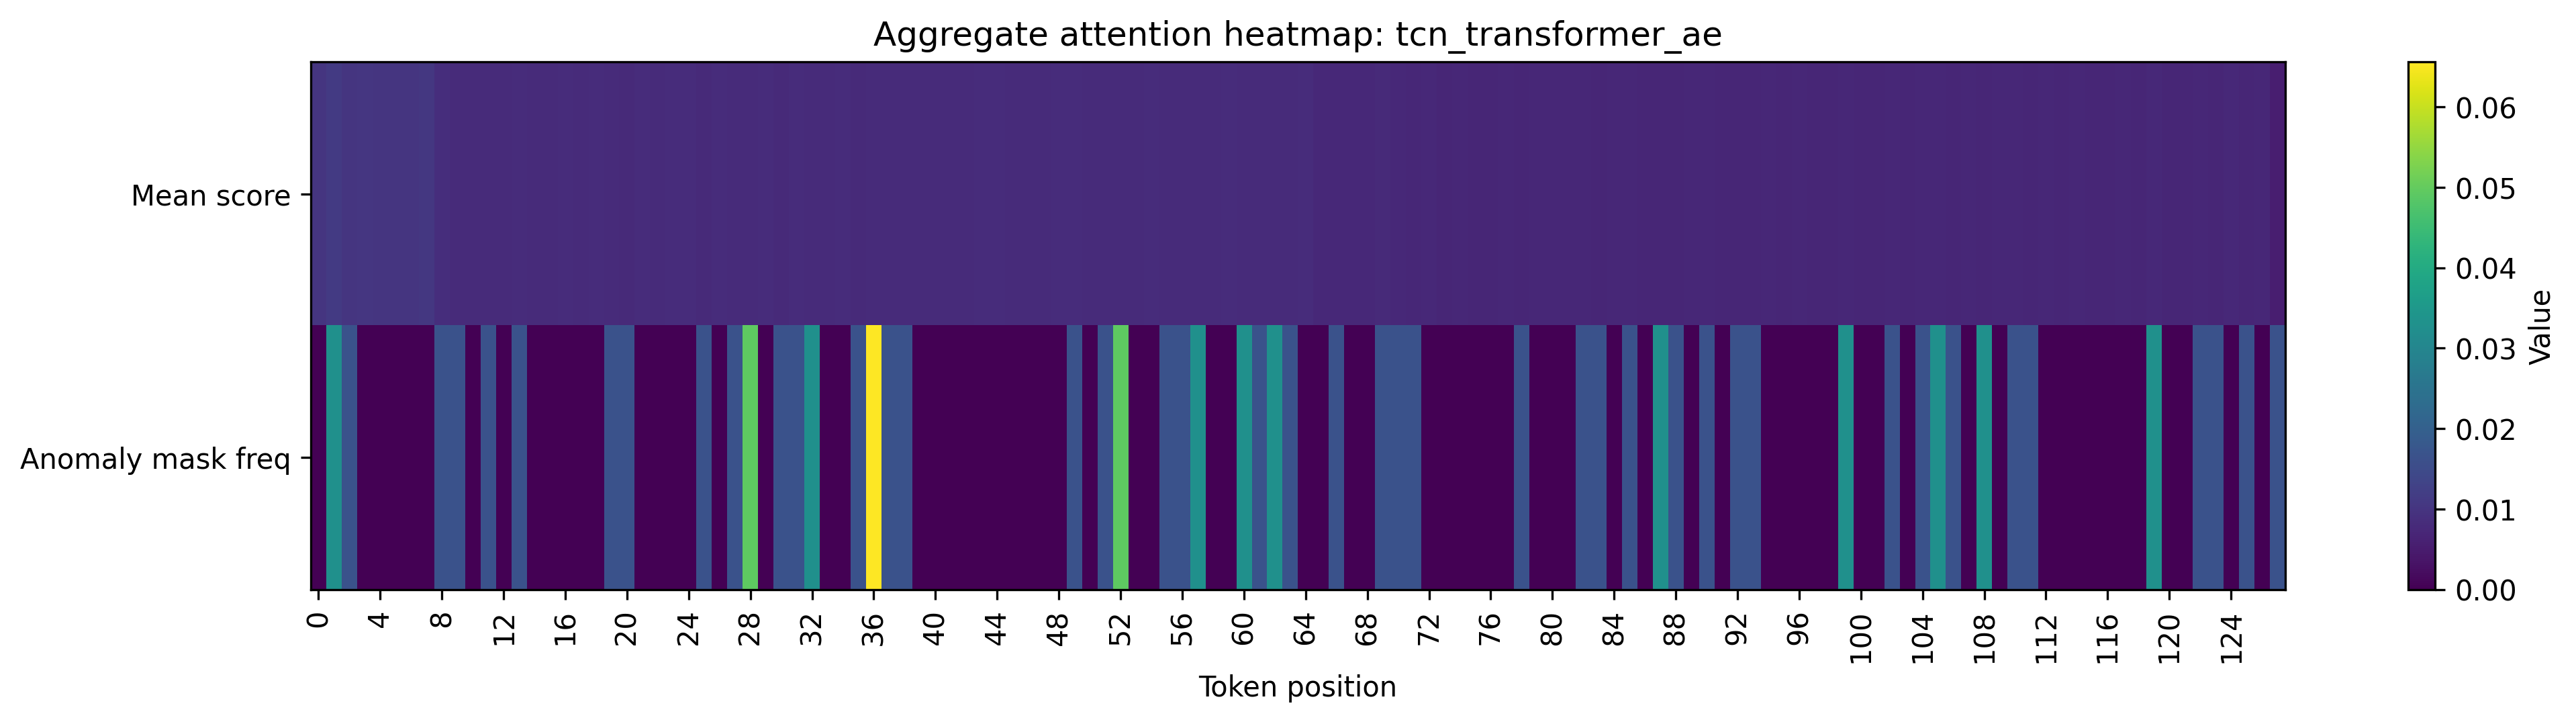

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

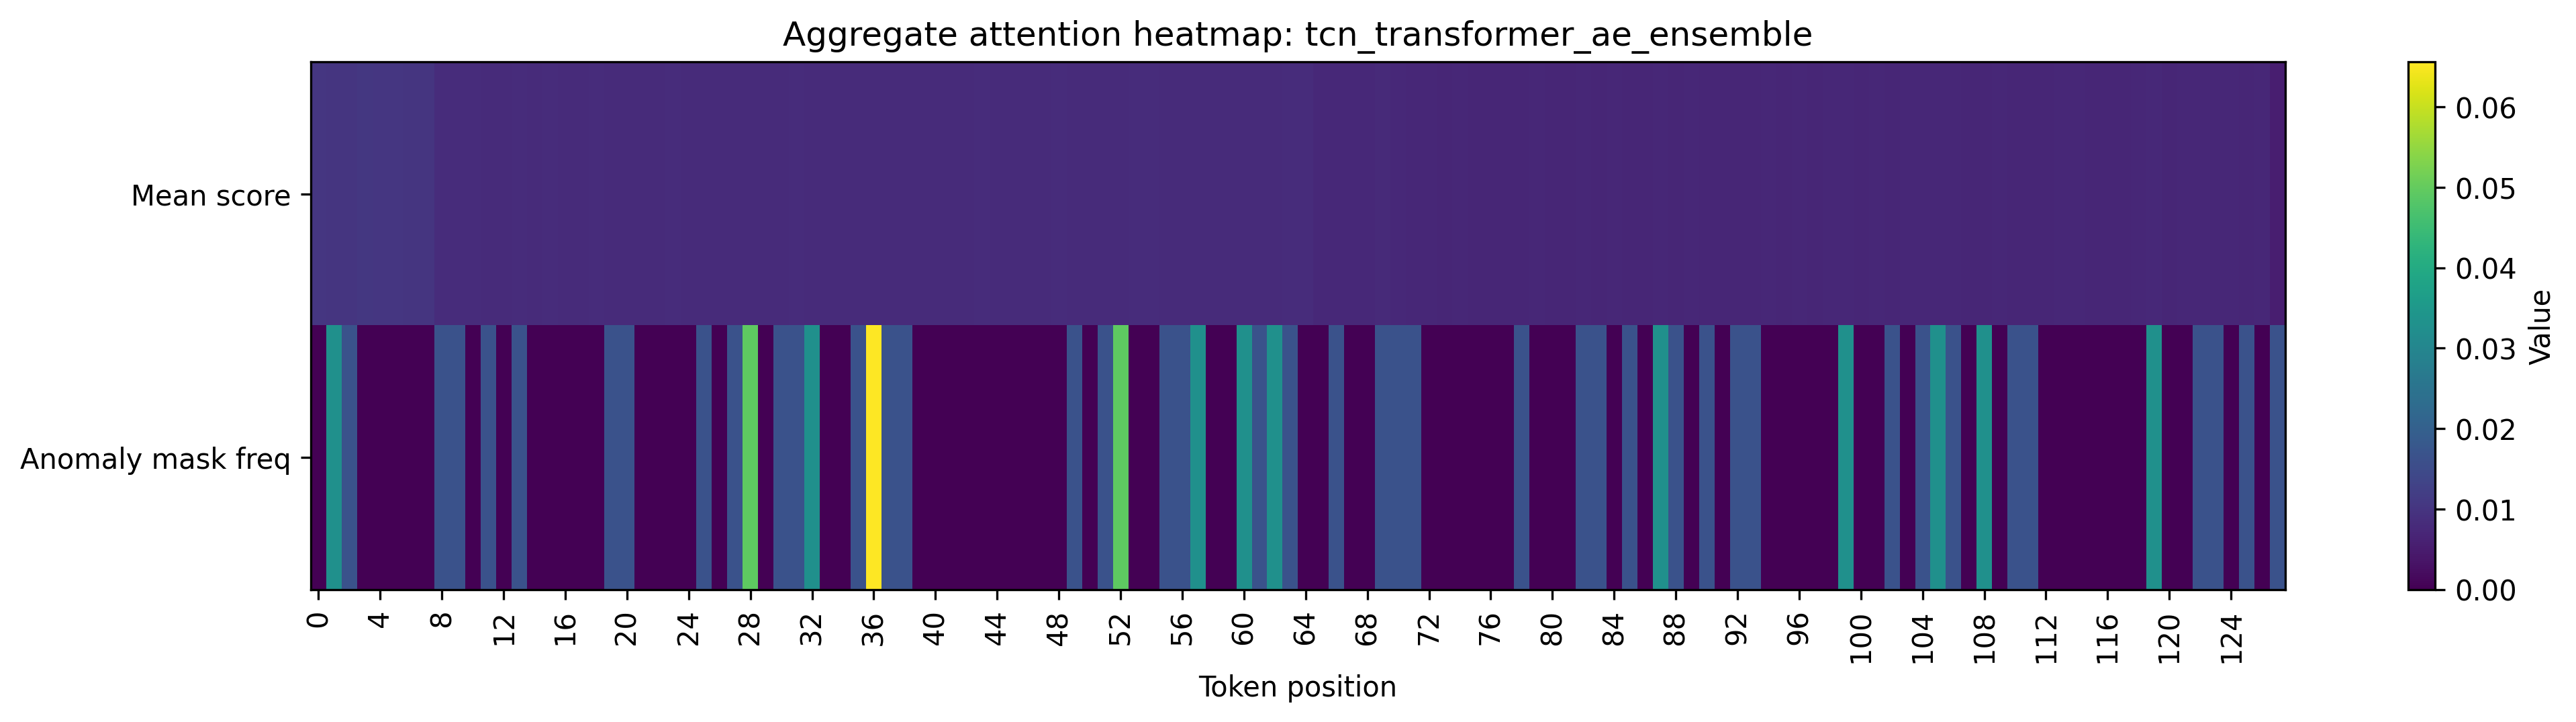

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

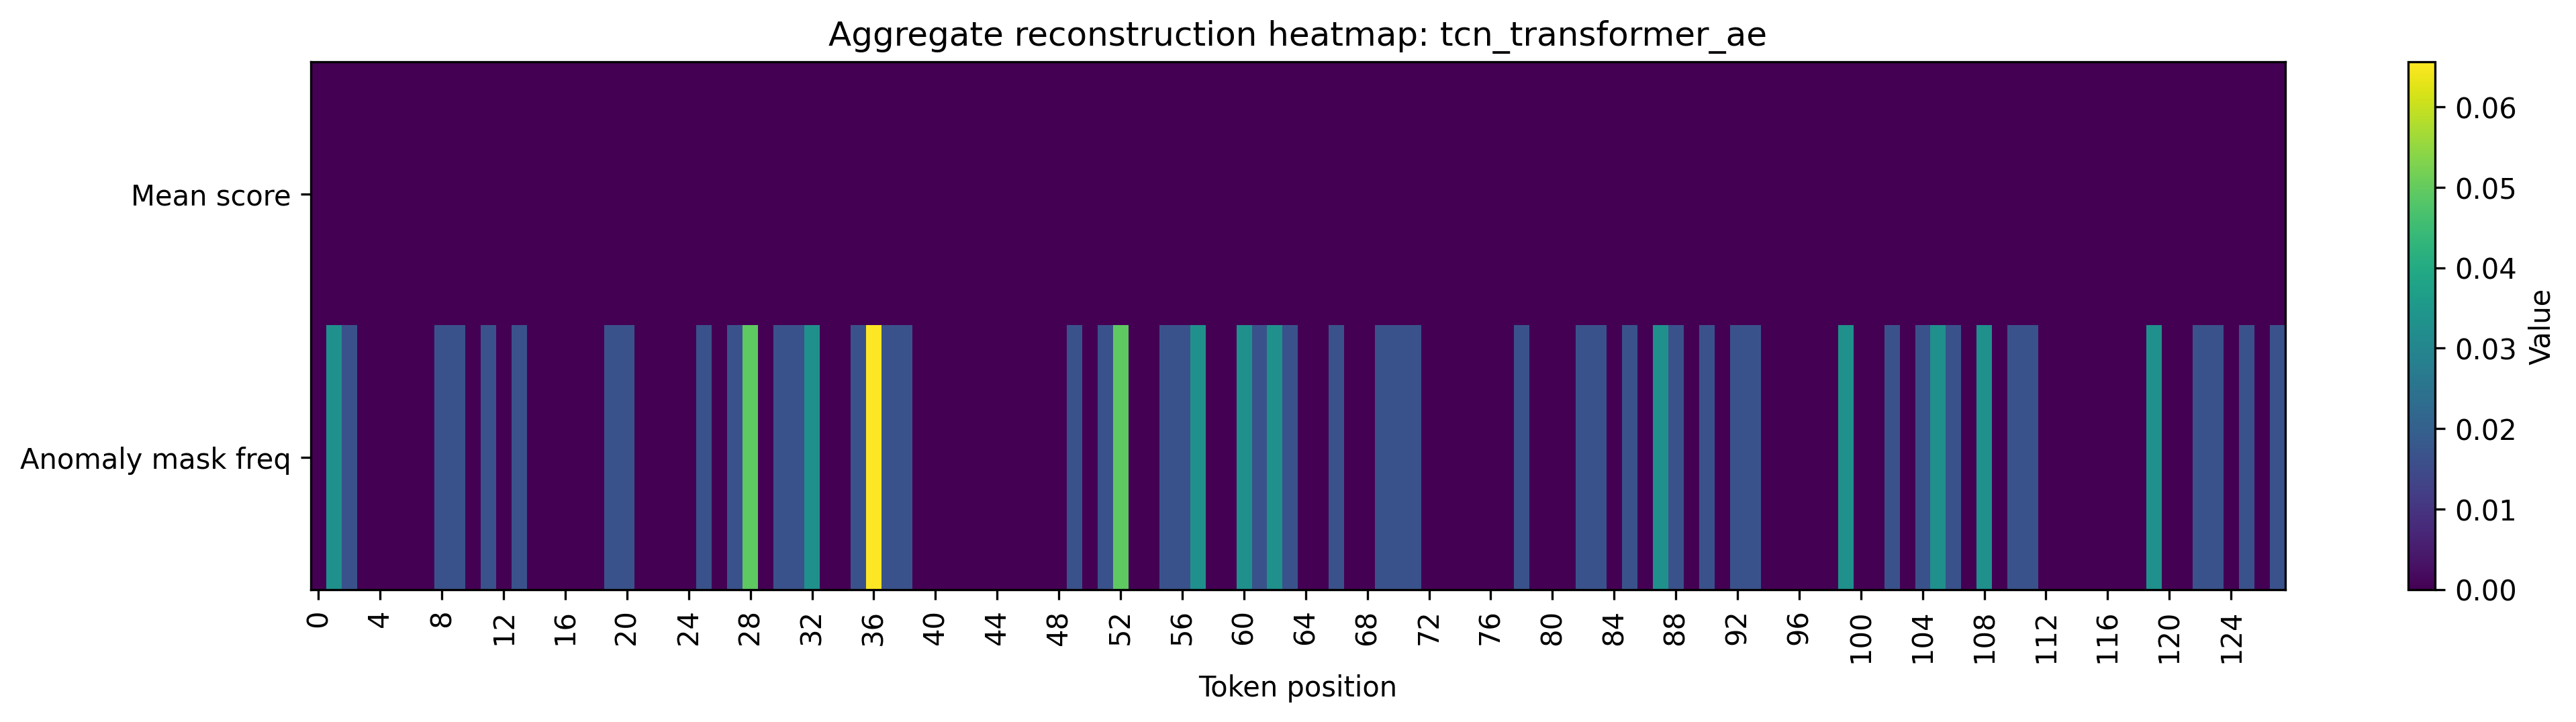

In [14]:
from IPython.display import Image, Markdown, display

for dataset_name, state in DATASET_STATE.items():
    figures_dir = state['output_dir'] / 'figures'
    display(Markdown(f'### {dataset_name}'))
    if not figures_dir.exists():
        display(Markdown(f'Нет папки с картинками: `{figures_dir}`'))
        continue

    confusion_paths = sorted(figures_dir.glob('confusion_matrix_*.png'))
    heatmap_paths = sorted(figures_dir.glob('aggregate_heatmap_*.png'))

    display(Markdown('**Матрицы ошибок**'))
    if confusion_paths:
        for path in confusion_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `confusion_matrix_*.png`. Запусти evaluation/report для этого датасета.'))

    display(Markdown('**Общие heatmap**'))
    if heatmap_paths:
        for path in heatmap_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `aggregate_heatmap_*.png`. Запусти localization/report для этого датасета.'))
